# 병합 데이터셋 EDA (Exploratory Data Analysis)

이 노트북은 B2(POS 영수증 매출)와 B4(상품별 분류) 데이터를 병합한 데이터셋에 대한 탐색적 데이터 분석을 수행합니다.

**데이터셋 경로:** `병합_데이터셋/df_B2_B4.parquet`

## 0. 환경 설정 및 라이브러리 임포트

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ★ 시각화 스타일을 먼저 설정 (이 호출이 font.family를 리셋함)
sns.set_style('whitegrid')

# ★ 한글 폰트 설정은 sns.set_style 이후에 해야 덮어쓰기되지 않음
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (15, 6)

print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 및 기본 정보 확인

In [2]:
# 병합 데이터셋 로드
df = pd.read_parquet('병합_데이터셋/df_B2_B4.parquet')
print(f'데이터 shape: {df.shape}')
print(f'\n컬럼 목록:')
print(df.columns.tolist())
print(f'\n데이터 타입:')
print(df.dtypes)
print(f'\n처음 5행:')
df.head()

데이터 shape: (49757758, 19)

컬럼 목록:
['영업일자', '판매시분초', '점포코드', 'POS번호', '거래번호', '상품코드', '매출수량', '매출금액', '판매시간_dt', '판매월', '판매일', '판매주', '판매요일', '판매시간대', '거래_복합키', '상품명', '상품대분류명', '상품중분류명', '상품소분류명']

데이터 타입:
영업일자                int64
판매시분초               int64
점포코드                int64
POS번호               int64
거래번호                int64
상품코드               object
매출수량                int32
매출금액                int32
판매시간_dt    datetime64[ns]
판매월                 int32
판매일                 int32
판매주                UInt32
판매요일                int32
판매시간대               int32
거래_복합키             object
상품명                object
상품대분류명             object
상품중분류명             object
상품소분류명             object
dtype: object

처음 5행:


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,판매시간_dt,판매월,판매일,판매주,판매요일,판매시간대,거래_복합키,상품명,상품대분류명,상품중분류명,상품소분류명
0,20250523,84531,64139,2,26651,314952,1,500,2025-05-23 08:45:31,5,23,21,4,8,64139_2_26651,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기
1,20250523,105724,52657,1,48727,314954,10,45000,2025-05-23 10:57:24,5,23,21,4,10,52657_1_48727,K)MIIX 믹스(릴 하이브리드),담배,국산담배,KT&G(전자담배용 담배)
2,20250523,105724,52657,1,48727,314952,10,5000,2025-05-23 10:57:24,5,23,21,4,10,52657_1_48727,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기
3,20250523,84531,64139,2,26651,314983,1,4500,2025-05-23 08:45:31,5,23,21,4,8,64139_2_26651,K)MIIX 아이스더블,담배,국산담배,KT&G(전자담배용 담배)
4,20250523,83823,50134,1,67971,314988,1,4500,2025-05-23 08:38:23,5,23,21,4,8,50134_1_67971,K)에쎄 히말라야1mg,담배,국산담배,KT&G(일반담배)


In [3]:
# 기본 통계 정보
print('=== 기본 통계 정보 ===')
df.describe()

=== 기본 통계 정보 ===


,영업일자,판매시분초,점포코드,POS번호,거래번호,매출수량,매출금액,판매시간_dt,판매월,판매일,판매주,판매요일,판매시간대
count,4.975776e+07,4.975776e+07,4.975776e+07,4.975776e+07,4.975776e+07,4.975776e+07,4.975776e+07,49757758,4.975776e+07,4.975776e+07,49757758.0,4.975776e+07,4.975776e+07
mean,2.025038e+07,1.441911e+05,3.913811e+04,1.633208e+00,4.866065e+04,1.317542e+00,3.265639e+03,2025-04-05 04:49:19.225730816,3.622186e+00,1.577416e+01,14.228414,2.992796e+00,1.412060e+01
min,2.025010e+07,0.000000e+00,1.000100e+04,1.000000e+00,1.000000e+00,-2.000000e+03,-1.300000e+09,2025-01-01 00:00:01,1.000000e+00,1.000000e+00,1.0,0.000000e+00,0.000000e+00
25%,2.025022e+07,1.023510e+05,1.499400e+04,1.000000e+00,2.294800e+04,1.000000e+00,1.500000e+03,2025-02-20 14:40:40,2.000000e+00,8.000000e+00,8.0,1.000000e+00,1.000000e+01
50%,2.025041e+07,1.527050e+05,5.122400e+04,2.000000e+00,4.764300e+04,1.000000e+00,2.300000e+03,2025-04-07 01:16:51,4.000000e+00,1.600000e+01,15.0,3.000000e+00,1.500000e+01
75%,2.025052e+07,1.939140e+05,5.965300e+04,2.000000e+00,7.408500e+04,1.000000e+00,4.500000e+03,2025-05-20 08:26:23,5.000000e+00,2.300000e+01,21.0,5.000000e+00,1.900000e+01
max,2.025063e+07,2.359590e+05,6.916300e+04,9.900000e+01,9.999900e+04,2.000000e+03,1.300000e+09,2025-06-30 23:59:58,6.000000e+00,3.100000e+01,27.0,6.000000e+00,2.300000e+01
std,1.694472e+02,6.116960e+04,2.321750e+04,1.886792e+00,2.921181e+04,2.991067e+00,3.687667e+05,NaN,1.690554e+00,8.655441e+00,7.40311,1.963999e+00,6.116854e+00


In [4]:
# 결측치 확인
print('=== 결측치 현황 ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '결측치 비율(%)': missing_pct})
print(missing_df[missing_df['결측치 수'] > 0])
print(f'\n전체 행 수: {len(df):,}')

=== 결측치 현황 ===
Empty DataFrame
Columns: [결측치 수, 결측치 비율(%)]
Index: []

전체 행 수: 49,757,758


## 2. 데이터 전처리

병합 데이터셋에서 필요한 전처리를 수행합니다.

In [5]:
# 시간 파생변수 확인 / 생성
# 판매시간_dt 컬럼이 있으면 파생변수 확인, 없으면 생성
time_cols = ['판매시간_dt', '판매월', '판매주', '판매요일', '판매시간대']
existing = [c for c in time_cols if c in df.columns]
missing_cols = [c for c in time_cols if c not in df.columns]

print(f'이미 존재하는 시간 파생변수: {existing}')
print(f'생성 필요한 시간 파생변수: {missing_cols}')

if '판매시간_dt' not in df.columns:
    # 영업일자 + 판매시분초로 datetime 생성
    df['판매시간_dt'] = pd.to_datetime(
        df['영업일자'].astype(str) + df['판매시분초'].astype(str).str.zfill(6),
        format='%Y%m%d%H%M%S'
    )
    print('판매시간_dt 컬럼 생성 완료')

# datetime 타입 확인 및 변환
if df['판매시간_dt'].dtype != 'datetime64[ns]':
    df['판매시간_dt'] = pd.to_datetime(df['판매시간_dt'])

# 파생변수 생성
if '판매연도' not in df.columns:
    df['판매연도'] = df['판매시간_dt'].dt.year
if '판매월' not in df.columns:
    df['판매월'] = df['판매시간_dt'].dt.month
if '판매주' not in df.columns:
    df['판매주'] = df['판매시간_dt'].dt.isocalendar().week.astype(int)
if '판매요일' not in df.columns:
    df['판매요일'] = df['판매시간_dt'].dt.dayofweek  # 0=월, 6=일
if '판매시간대' not in df.columns:
    df['판매시간대'] = df['판매시간_dt'].dt.hour

print('\n시간 파생변수 확인:')
print(df[['판매시간_dt', '판매월', '판매주', '판매요일', '판매시간대']].head())

이미 존재하는 시간 파생변수: ['판매시간_dt', '판매월', '판매주', '판매요일', '판매시간대']
생성 필요한 시간 파생변수: []

시간 파생변수 확인:
              판매시간_dt  판매월  판매주  판매요일  판매시간대
0 2025-05-23 08:45:31    5   21     4      8
1 2025-05-23 10:57:24    5   21     4     10
2 2025-05-23 10:57:24    5   21     4     10
3 2025-05-23 08:45:31    5   21     4      8
4 2025-05-23 08:38:23    5   21     4      8


## 3. 병합 품질 검증

In [6]:
# 분류 정보 매핑 여부 확인
if '상품대분류명' in df.columns:
    unmapped = df['상품대분류명'].isna().sum()
    unmapped_pct = unmapped / len(df) * 100
    print(f'전체 행 수: {len(df):,}')
    print(f'분류 미매핑 수: {unmapped:,}')
    print(f'미매핑 비율: {unmapped_pct:.2f}%')
    print(f'\n매핑 완료 수: {len(df) - unmapped:,}')
else:
    print('상품대분류명 컬럼이 존재하지 않습니다. 병합이 정상적으로 수행되었는지 확인하세요.')

전체 행 수: 49,757,758
분류 미매핑 수: 0
미매핑 비율: 0.00%

매핑 완료 수: 49,757,758


In [7]:
# 미매핑 상품 분석 (분류 정보가 없는 상품)
if '상품대분류명' in df.columns:
    unmapped_items = df[df['상품대분류명'].isna()]
    if len(unmapped_items) > 0:
        print(f'미매핑 상품 코드 수: {unmapped_items["상품코드"].nunique()}')
        print(f'\n미매핑 상품의 매출금액 합계: {unmapped_items["매출금액"].sum():,}')
        print(f'전체 매출 대비 비율: {unmapped_items["매출금액"].sum() / df["매출금액"].sum() * 100:.2f}%')
    else:
        print('모든 상품이 정상적으로 매핑되었습니다.')

모든 상품이 정상적으로 매핑되었습니다.


## 4. 이상치 분석 (음수 매출)

In [8]:
# 음수 매출수량 분석
neg_qty = df[df['매출수량'] < 0]
print(f'음수 매출수량 행 수: {len(neg_qty):,}')
print(f'전체 대비 비율: {len(neg_qty) / len(df) * 100:.2f}%')
print(f'\n음수 매출수량 기본 통계:')
print(neg_qty['매출수량'].describe())

음수 매출수량 행 수: 1,056,894
전체 대비 비율: 2.12%

음수 매출수량 기본 통계:
count    1.056894e+06
mean    -2.137563e+00
std      1.078409e+01
min     -2.000000e+03
25%     -1.000000e+00
50%     -1.000000e+00
75%     -1.000000e+00
max     -1.000000e+00
Name: 매출수량, dtype: float64


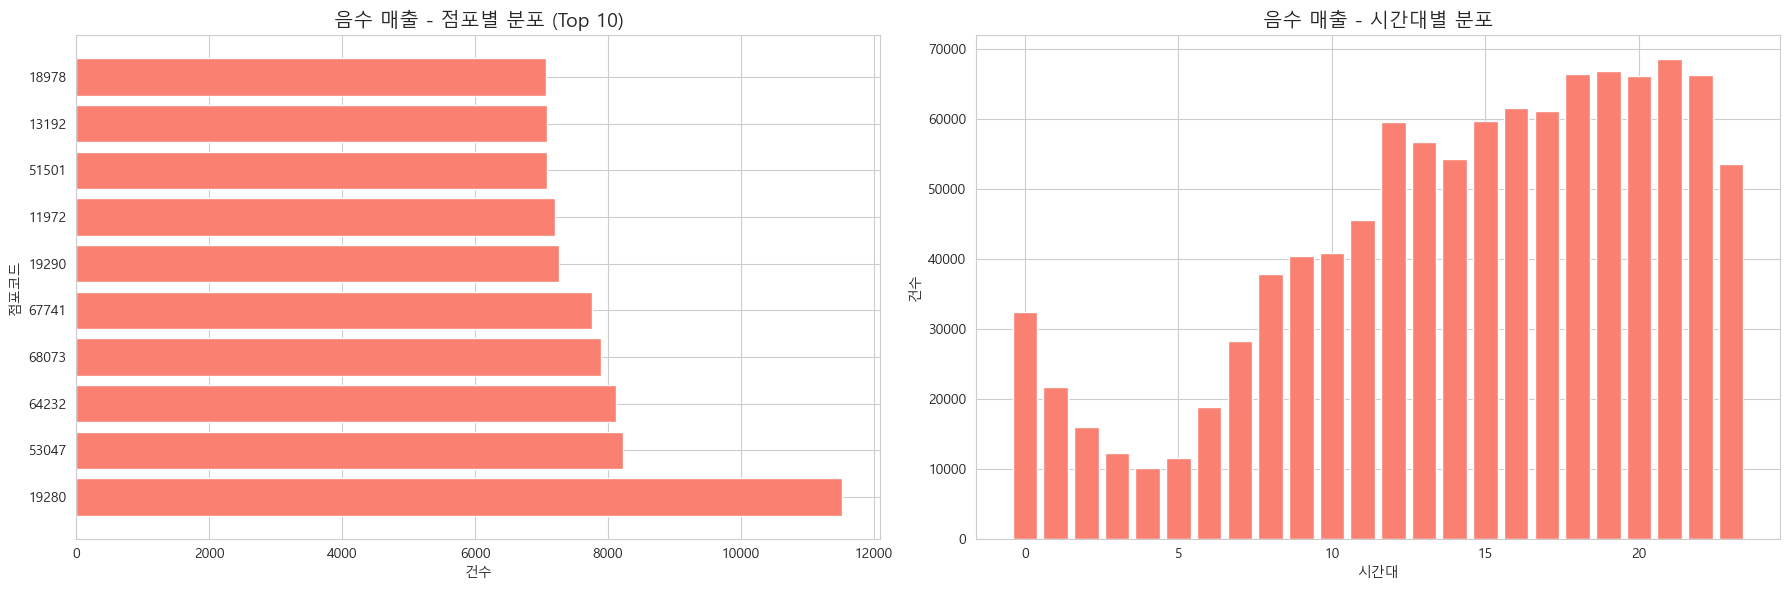

In [14]:
# 음수 매출의 점포별, 시간대별 분포
if len(neg_qty) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 점포별 음수 거래 분포 (상위 10개)
    top_stores = neg_qty['점포코드'].value_counts().head(10)
    axes[0].barh(range(len(top_stores)), top_stores.values, color='salmon')
    axes[0].set_yticks(range(len(top_stores)))
    axes[0].set_yticklabels(top_stores.index.astype(str))
    axes[0].set_title('음수 매출 - 점포별 분포 (Top 10)', fontsize=14)
    axes[0].set_xlabel('건수')
    axes[0].set_ylabel('점포코드')

    # 시간대별 음수 거래 분포
    if '판매시간대' in neg_qty.columns:
        hour_dist = neg_qty['판매시간대'].value_counts().sort_index()
        axes[1].bar(hour_dist.index, hour_dist.values, color='salmon')
        axes[1].set_title('음수 매출 - 시간대별 분포', fontsize=14)
        axes[1].set_xlabel('시간대')
        axes[1].set_ylabel('건수')

    plt.tight_layout()
    plt.show()

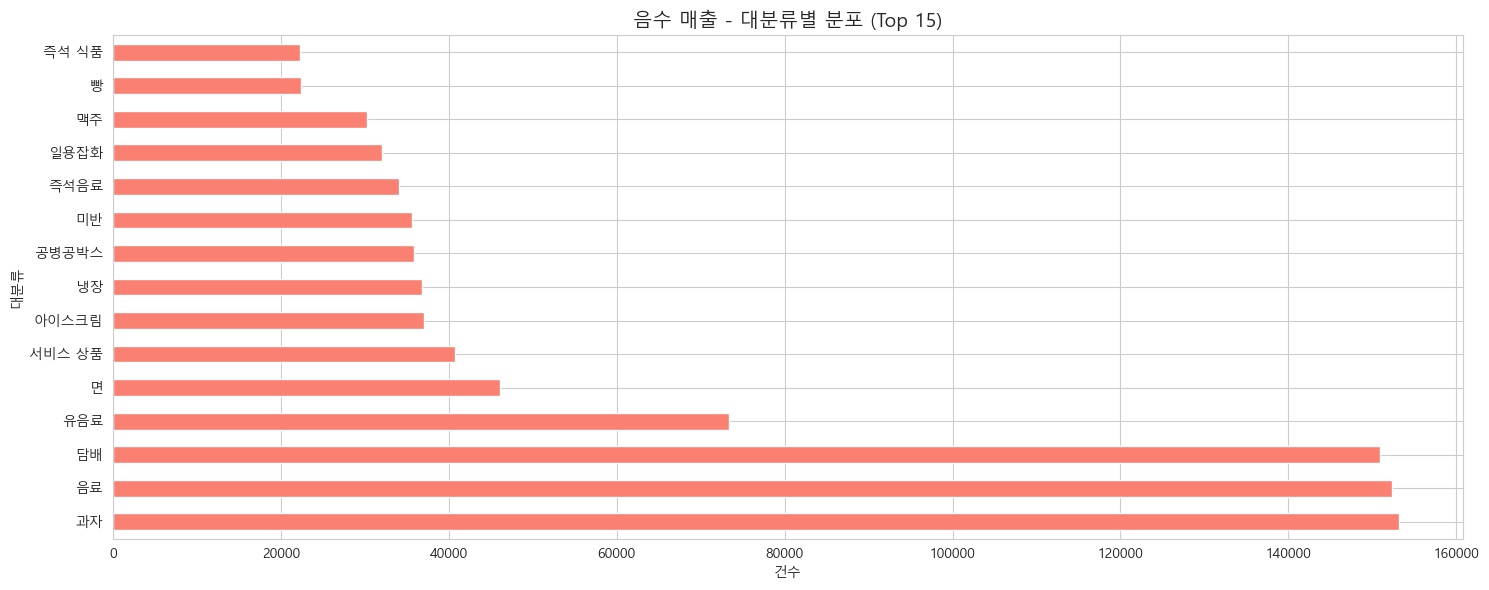

In [15]:
# 음수 매출의 대분류별 분포
if len(neg_qty) > 0 and '상품대분류명' in neg_qty.columns:
    neg_by_cat = neg_qty.groupby('상품대분류명')['매출수량'].count().sort_values(ascending=False)
    
    plt.figure(figsize=(15, 6))
    neg_by_cat.head(15).plot(kind='barh', color='salmon')
    plt.title('음수 매출 - 대분류별 분포 (Top 15)', fontsize=14)
    plt.xlabel('건수')
    plt.ylabel('대분류')
    plt.tight_layout()
    plt.show()

## 5. 시계열 분석

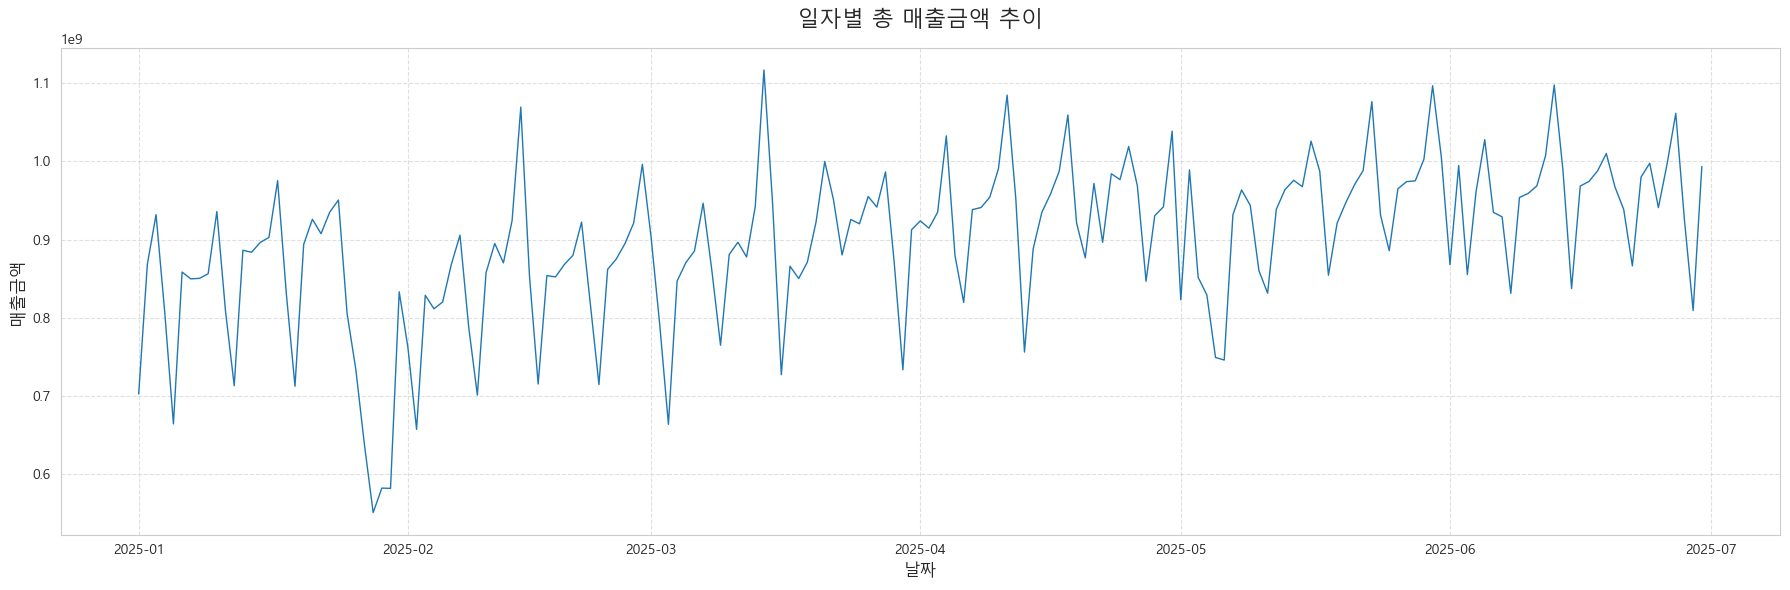


일 평균 매출금액: 897,739,643
최대 매출일: 2025-03-14 (1,117,203,593)
최소 매출일: 2025-01-28 (550,329,442)


In [16]:
# 일자별 매출금액 추이
daily_sales = df.groupby(df['판매시간_dt'].dt.date)['매출금액'].sum()

plt.figure(figsize=(18, 6))
daily_sales.plot(color='#1f77b4', linewidth=1)
plt.title('일자별 총 매출금액 추이', fontsize=16, pad=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('매출금액', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'\n일 평균 매출금액: {daily_sales.mean():,.0f}')
print(f'최대 매출일: {daily_sales.idxmax()} ({daily_sales.max():,.0f})')
print(f'최소 매출일: {daily_sales.idxmin()} ({daily_sales.min():,.0f})')

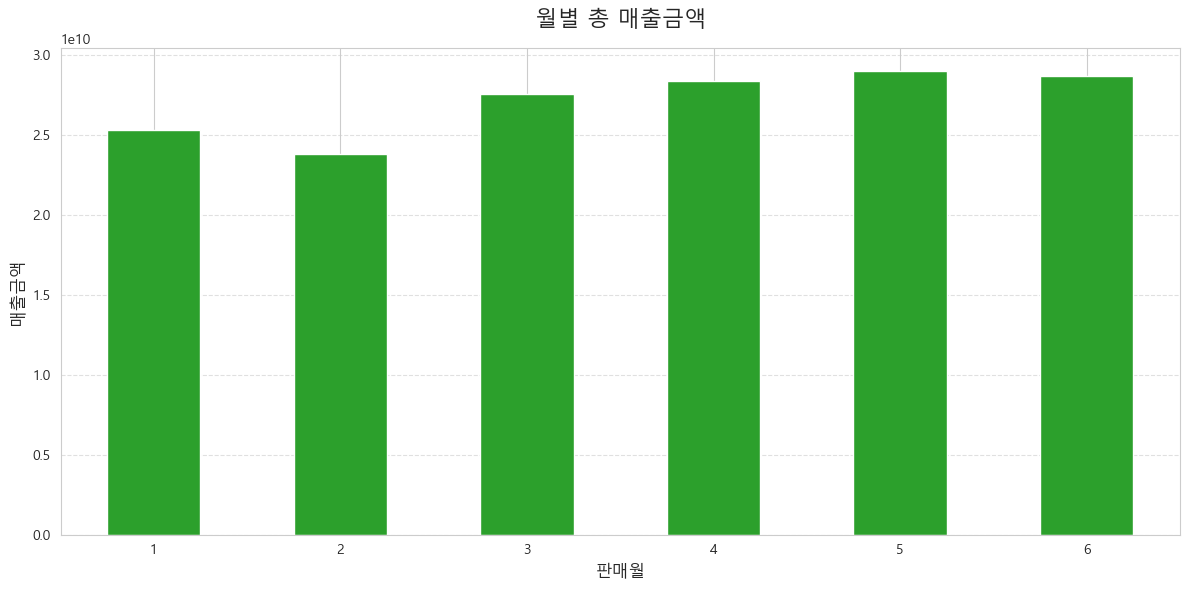


▼ 월별 매출금액 (높은 순) ▼
판매월
5    28973111106
6    28634085853
4    28324286565
3    27506566934
1    25268034008
2    23784790921
Name: 매출금액, dtype: int64


In [17]:
# 월별 매출금액 비교
monthly_sales = df.groupby('판매월')['매출금액'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar', color='#2ca02c', edgecolor='white')
plt.title('월별 총 매출금액', fontsize=16, pad=15)
plt.xlabel('판매월', fontsize=12)
plt.ylabel('매출금액', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.show()

print('\n▼ 월별 매출금액 (높은 순) ▼')
print(monthly_sales.sort_values(ascending=False))

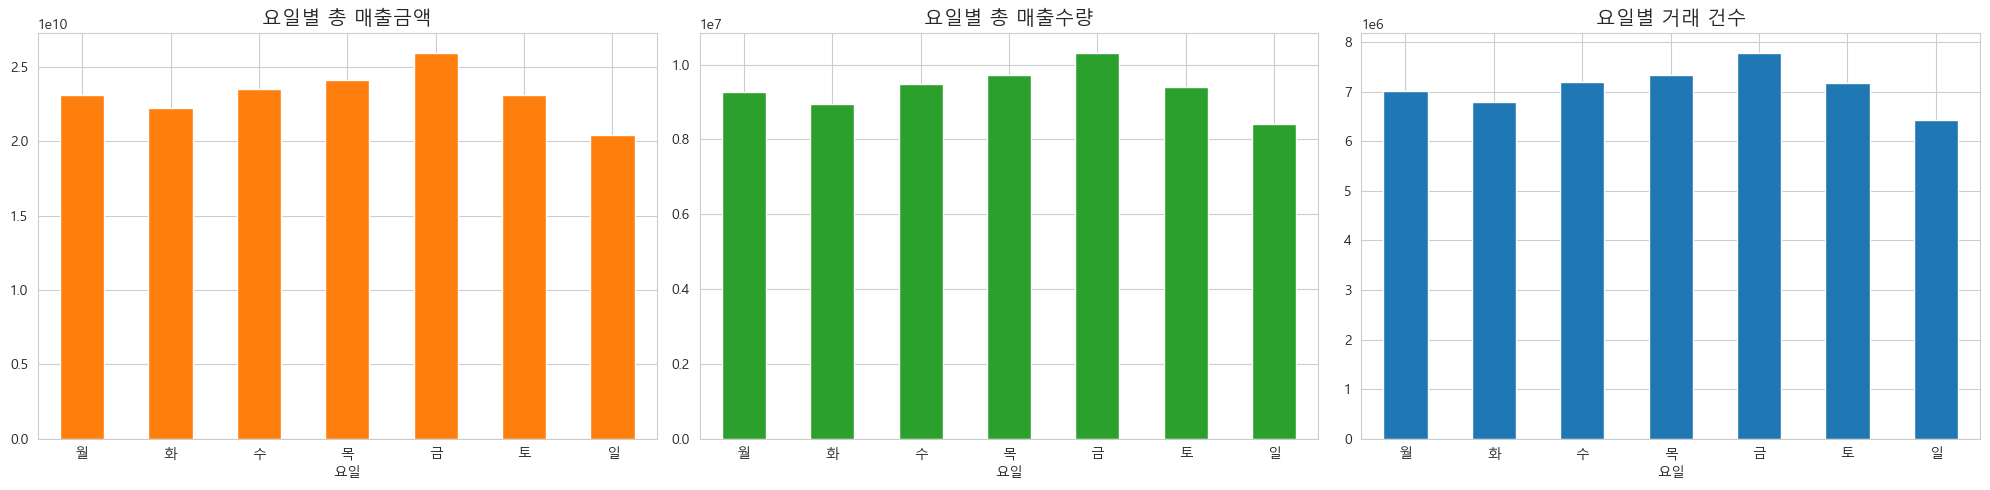

In [18]:
# 요일별 매출 패턴
요일이름 = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
weekly_sales = df.groupby('판매요일').agg(
    매출금액합계=('매출금액', 'sum'),
    매출수량합계=('매출수량', 'sum'),
    거래건수=('판매시간_dt', 'count')
)
weekly_sales.index = weekly_sales.index.map(요일이름)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

weekly_sales['매출금액합계'].plot(kind='bar', ax=axes[0], color='#ff7f0e', edgecolor='white')
axes[0].set_title('요일별 총 매출금액', fontsize=14)
axes[0].set_xlabel('요일')
axes[0].tick_params(axis='x', rotation=0)

weekly_sales['매출수량합계'].plot(kind='bar', ax=axes[1], color='#2ca02c', edgecolor='white')
axes[1].set_title('요일별 총 매출수량', fontsize=14)
axes[1].set_xlabel('요일')
axes[1].tick_params(axis='x', rotation=0)

weekly_sales['거래건수'].plot(kind='bar', ax=axes[2], color='#1f77b4', edgecolor='white')
axes[2].set_title('요일별 거래 건수', fontsize=14)
axes[2].set_xlabel('요일')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

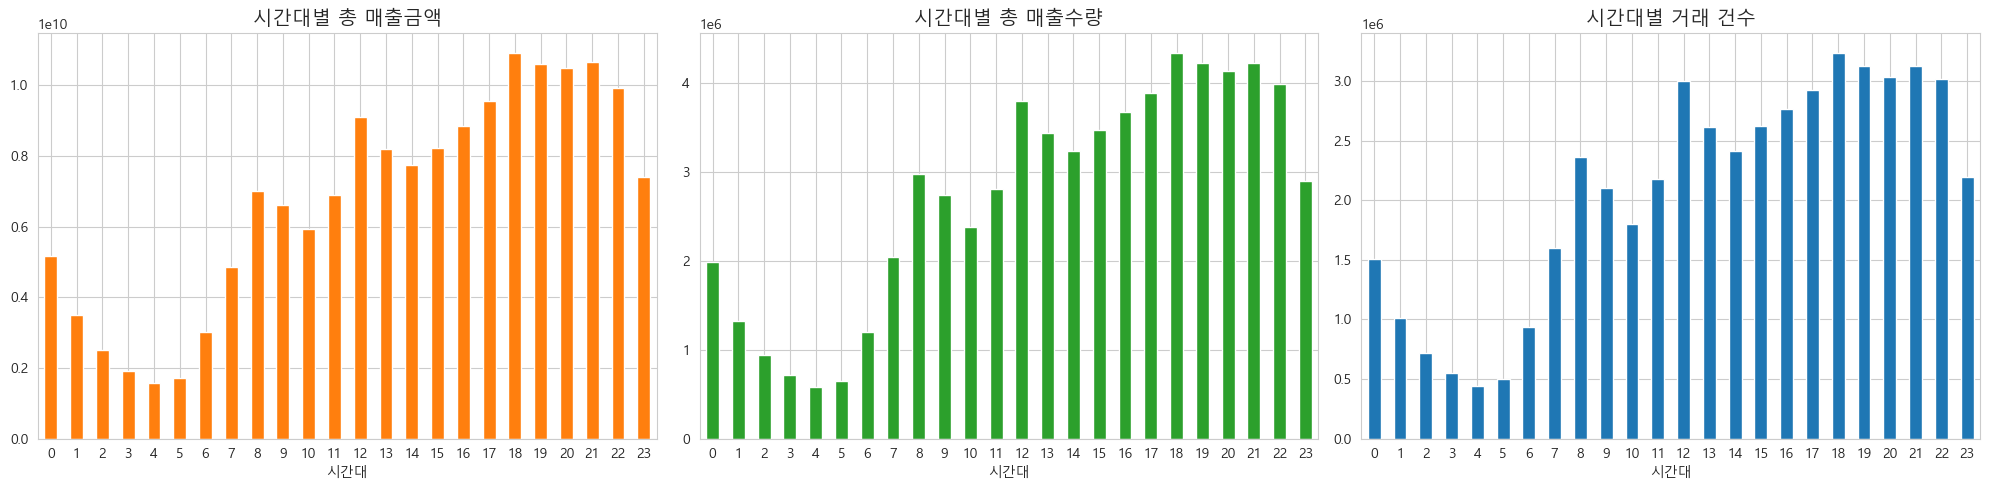


▼ 피크 시간대 (매출금액 기준 Top 5) ▼
판매시간대
18    10927112950
21    10678725908
19    10613865936
20    10502954979
22     9936605290
Name: 매출금액합계, dtype: int64


In [19]:
# 시간대별 매출 패턴
hourly_sales = df.groupby('판매시간대').agg(
    매출금액합계=('매출금액', 'sum'),
    매출수량합계=('매출수량', 'sum'),
    거래건수=('판매시간_dt', 'count')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

hourly_sales['매출금액합계'].plot(kind='bar', ax=axes[0], color='#ff7f0e', edgecolor='white')
axes[0].set_title('시간대별 총 매출금액', fontsize=14)
axes[0].set_xlabel('시간대')
axes[0].tick_params(axis='x', rotation=0)

hourly_sales['매출수량합계'].plot(kind='bar', ax=axes[1], color='#2ca02c', edgecolor='white')
axes[1].set_title('시간대별 총 매출수량', fontsize=14)
axes[1].set_xlabel('시간대')
axes[1].tick_params(axis='x', rotation=0)

hourly_sales['거래건수'].plot(kind='bar', ax=axes[2], color='#1f77b4', edgecolor='white')
axes[2].set_title('시간대별 거래 건수', fontsize=14)
axes[2].set_xlabel('시간대')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\n▼ 피크 시간대 (매출금액 기준 Top 5) ▼')
print(hourly_sales['매출금액합계'].sort_values(ascending=False).head())

## 6. 점포 분석

In [20]:
# 점포 수 확인
n_stores = df['점포코드'].nunique()
print(f'전체 점포 수: {n_stores}')

# 점포별 매출금액 분석
store_sales = df.groupby('점포코드').agg(
    매출금액합계=('매출금액', 'sum'),
    매출수량합계=('매출수량', 'sum'),
    거래건수=('판매시간_dt', 'count')
)

print(f'\n▼ 점포별 매출금액 통계 ▼')
print(store_sales['매출금액합계'].describe())

전체 점포 수: 448

▼ 점포별 매출금액 통계 ▼
count    4.480000e+02
mean     3.627028e+08
std      2.061707e+08
min      9.355279e+06
25%      2.438498e+08
50%      3.176604e+08
75%      4.388784e+08
max      1.488099e+09
Name: 매출금액합계, dtype: float64


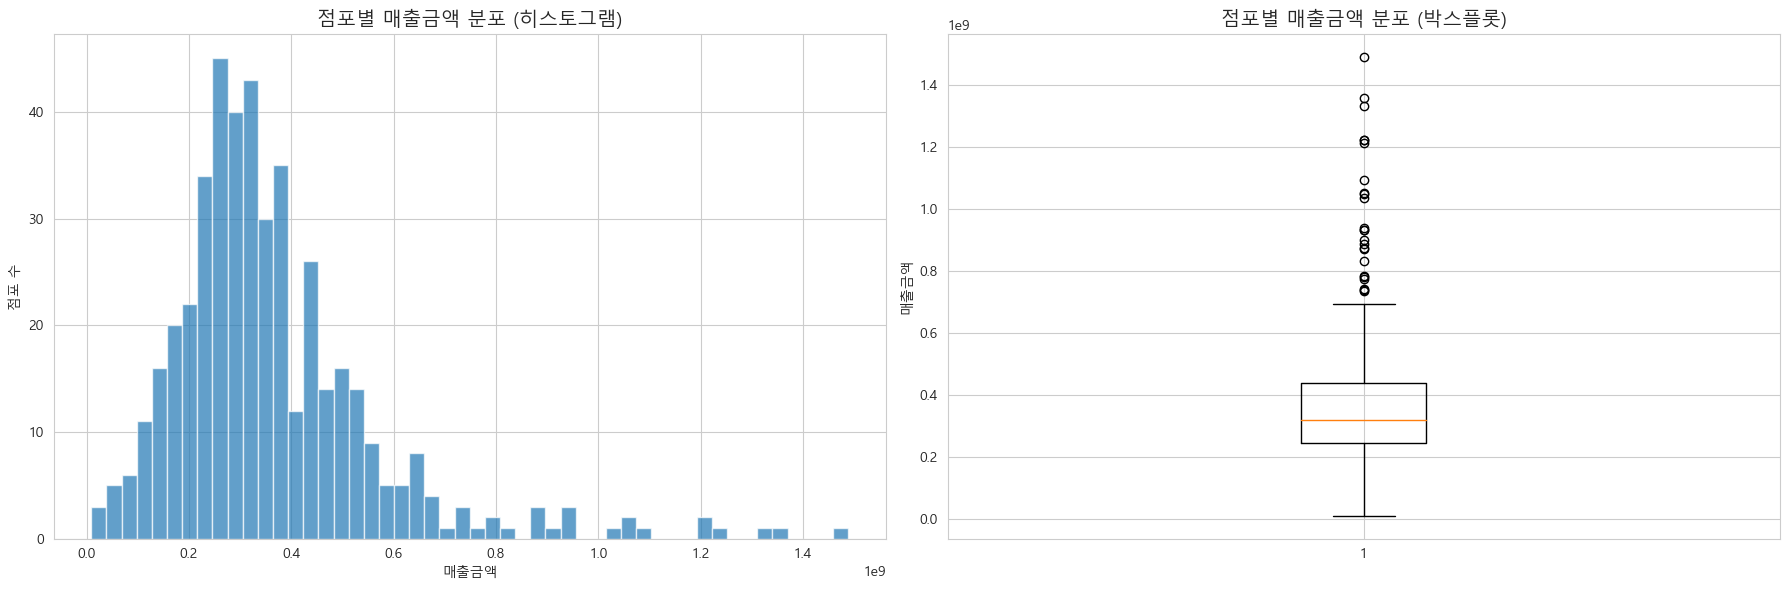

In [21]:
# 점포별 매출금액 분포
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 히스토그램
axes[0].hist(store_sales['매출금액합계'], bins=50, color='#1f77b4', edgecolor='white', alpha=0.7)
axes[0].set_title('점포별 매출금액 분포 (히스토그램)', fontsize=14)
axes[0].set_xlabel('매출금액')
axes[0].set_ylabel('점포 수')

# 박스플롯
axes[1].boxplot(store_sales['매출금액합계'], vert=True)
axes[1].set_title('점포별 매출금액 분포 (박스플롯)', fontsize=14)
axes[1].set_ylabel('매출금액')

plt.tight_layout()
plt.show()

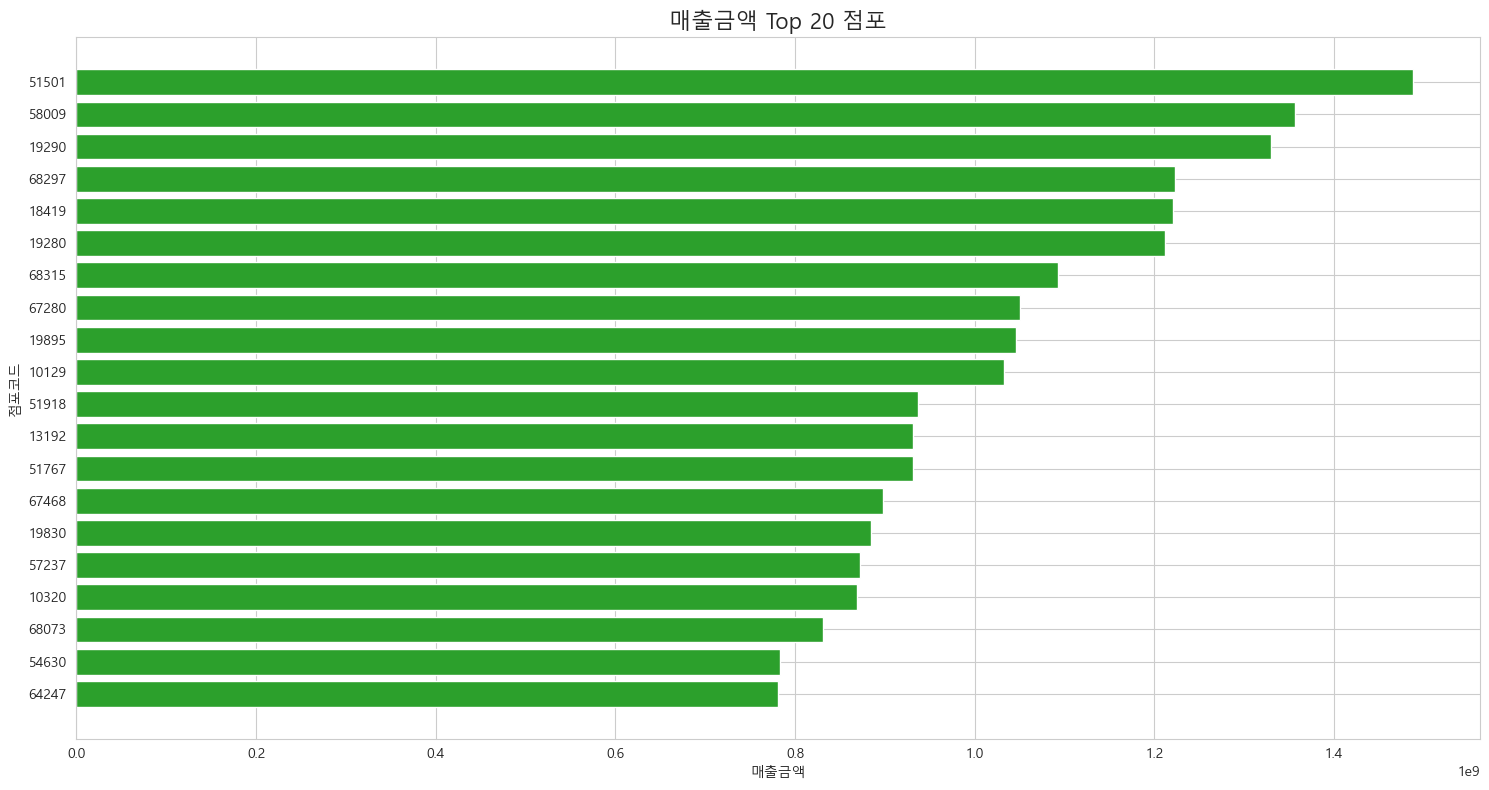

In [22]:
# 매출 Top 20 점포
top20_stores = store_sales.nlargest(20, '매출금액합계')

plt.figure(figsize=(15, 8))
plt.barh(range(len(top20_stores)), top20_stores['매출금액합계'].values, color='#2ca02c')
plt.yticks(range(len(top20_stores)), top20_stores.index.astype(str))
plt.title('매출금액 Top 20 점포', fontsize=16)
plt.xlabel('매출금액')
plt.ylabel('점포코드')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. 거래 분석

In [23]:
# 거래당 분석
transaction_summary = df.groupby('거래_복합키').agg(
    상품수=('상품코드', 'count'),
    매출금액합계=('매출금액', 'sum')
)

print(f'총 거래 건수: {len(transaction_summary):,}')
print(f'\n거래당 평균 상품 수: {transaction_summary["상품수"].mean():.2f}')
print(f'거래당 평균 매출금액: {transaction_summary["매출금액합계"].mean():,.0f}')
print(f'\n거래당 매출금액 통계:')
print(transaction_summary['매출금액합계'].describe())

총 거래 건수: 25,633,818

거래당 평균 상품 수: 1.94
거래당 평균 매출금액: 6,339

거래당 매출금액 통계:
count    2.563382e+07
mean     6.338926e+03
std      1.644066e+04
min     -9.000000e+06
25%      2.400000e+03
50%      4.500000e+03
75%      7.600000e+03
max      2.880000e+07
Name: 매출금액합계, dtype: float64


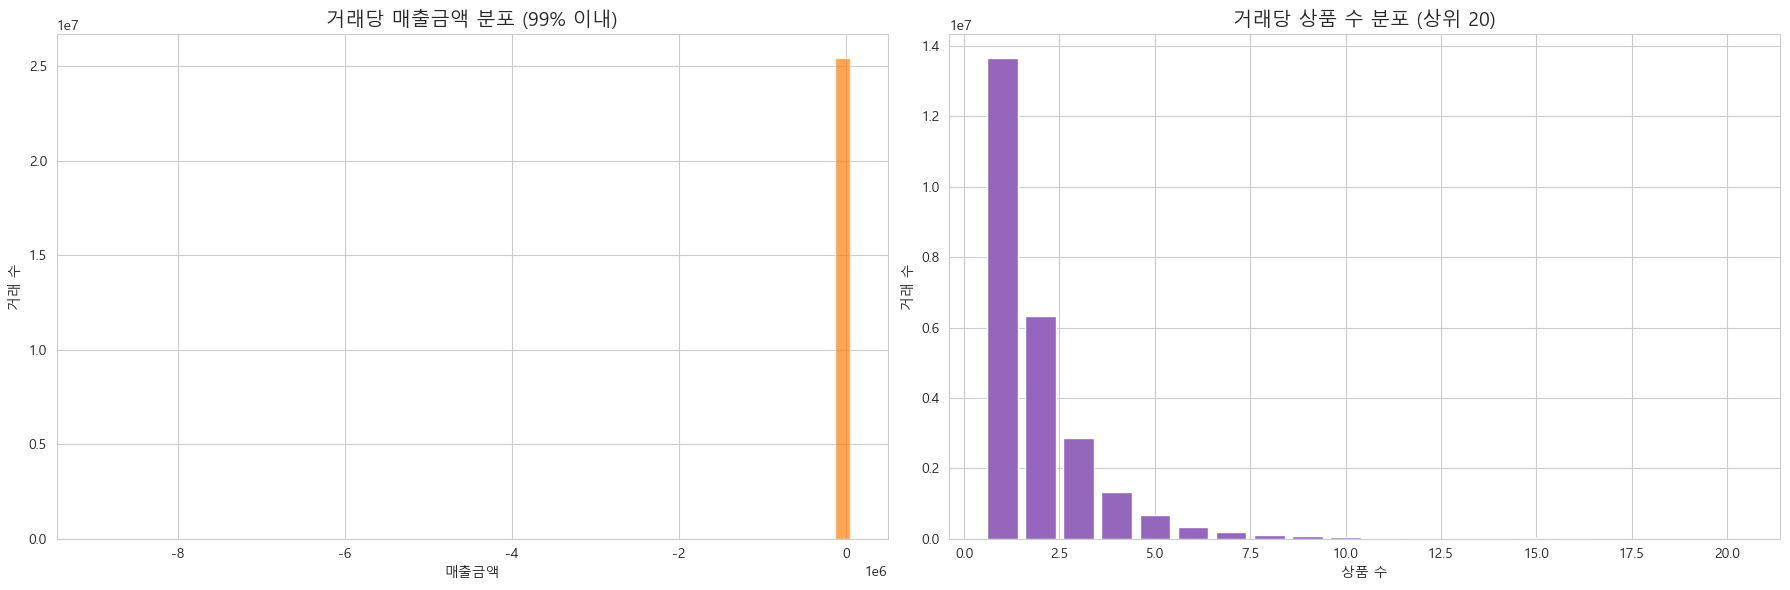

In [24]:
# 거래당 매출금액 분포
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 히스토그램 (극단값 제외)
q99 = transaction_summary['매출금액합계'].quantile(0.99)
filtered = transaction_summary[transaction_summary['매출금액합계'] <= q99]['매출금액합계']
axes[0].hist(filtered, bins=50, color='#ff7f0e', edgecolor='white', alpha=0.7)
axes[0].set_title('거래당 매출금액 분포 (99% 이내)', fontsize=14)
axes[0].set_xlabel('매출금액')
axes[0].set_ylabel('거래 수')

# 거래당 상품 수 분포
items_per_trx = transaction_summary['상품수'].value_counts().sort_index().head(20)
axes[1].bar(items_per_trx.index, items_per_trx.values, color='#9467bd', edgecolor='white')
axes[1].set_title('거래당 상품 수 분포 (상위 20)', fontsize=14)
axes[1].set_xlabel('상품 수')
axes[1].set_ylabel('거래 수')

plt.tight_layout()
plt.show()

## 8. 카테고리(대분류) 기반 매출 분석

In [27]:
# 대분류별 매출 분석
if '상품대분류명' in df.columns:
    cat_sales = df.groupby('상품대분류명').agg(
        매출금액합계=('매출금액', 'sum'),
        매출수량합계=('매출수량', 'sum'),
        거래건수=('판매시간_dt', 'count')
    ).sort_values('매출금액합계', ascending=False)

    print('▼ 대분류별 매출금액 ▼')
    display(cat_sales)
else:
    print('상품대분류명 컬럼이 없습니다.')

▼ 대분류별 매출금액 ▼


,매출금액합계,매출수량합계,거래건수
상품대분류명,,,
담배,55314091900,12915594,8835147
음료,20313593196,12236577,8898417
과자,13800855389,7709963,6775359
유음료,9766324946,5605592,4372351
맥주,7663867312,2334404,1222474
미반,7462917310,2989206,3002799
양주와인,4197419215,397210,320288
면,4135709930,2701154,2418480
냉장,4001505808,1711870,1362073


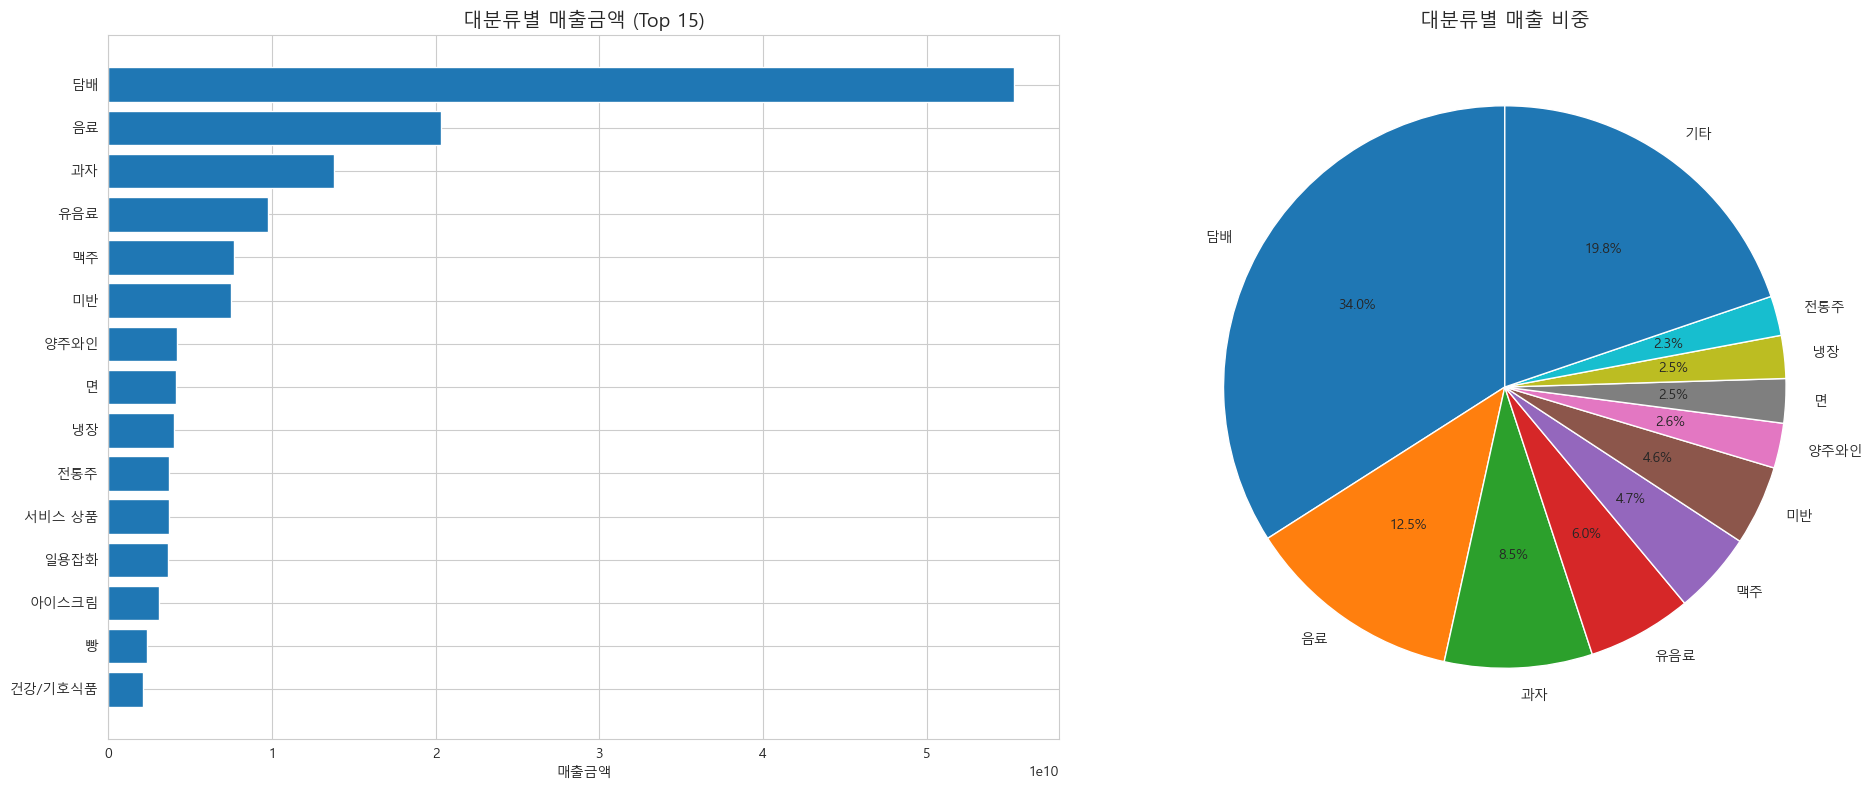

In [28]:
# 대분류별 매출 시각화
if '상품대분류명' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # 바 차트 (상위 15개)
    top15 = cat_sales.head(15)
    axes[0].barh(range(len(top15)), top15['매출금액합계'].values, color='#1f77b4')
    axes[0].set_yticks(range(len(top15)))
    axes[0].set_yticklabels(top15.index)
    axes[0].set_title('대분류별 매출금액 (Top 15)', fontsize=14)
    axes[0].set_xlabel('매출금액')
    axes[0].invert_yaxis()

    # 파이 차트 (상위 10개 + 기타)
    top10 = cat_sales.head(10)['매출금액합계']
    others = cat_sales.iloc[10:]['매출금액합계'].sum()
    pie_data = pd.concat([top10, pd.Series({'기타': others})])
    axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('대분류별 매출 비중', fontsize=14)

    plt.tight_layout()
    plt.show()

## 9. 상품 분석 (카테고리 정보 활용)

In [33]:
# 고유 상품 수
n_products = df['상품코드'].nunique()
print(f'고유 상품 수: {n_products:,}')

# 매출금액 Top 20 상품
if '상품명' in df.columns:
    top20_products = (
        df.groupby(['상품코드', '상품명'])['매출금액']
        .sum()
        .nlargest(20)
        .reset_index()
    )
    print('\n▼ 매출금액 Top 20 상품 ▼')
    print(top20_products.to_string(index=False))
else:
    top20_products = (
        df.groupby('상품코드')['매출금액']
        .sum()
        .nlargest(20)
        .reset_index()
    )
    print('\n▼ 매출금액 Top 20 상품 ▼')
    print(top20_products.to_string(index=False))

고유 상품 수: 12,602

▼ 매출금액 Top 20 상품 ▼
  상품코드                상품명       매출금액
314631         K)에쎄체인지1mg 1471905000
314954 K)MIIX 믹스(릴 하이브리드) 1388754000
300112     J)메비우스스카이블루(곽) 1358131500
315275           P)테리아 블루 1274952000
314983       K)MIIX 아이스더블 1233193500
315279        P)테리아 퍼플웨이브 1228852800
315361        P)테리아 오아시스펄 1064899200
315107      B)던힐 6mg(NEW) 1054714500
300115        P)말보로골드오리지널 1049571000
315278         P)테리아 블랙퍼플 1009886400
315109      B)던힐 1mg(NEW)  962154000
315276           P)테리아 그린  935222400
314767          K)레종프렌치블랙  894433500
315273           P)테리아 실버  849187200
314988       K)에쎄 히말라야1mg  825291000
315100       K)MIIX 아이스 뱅  822928500
070012     빙그레)바나나우유240ml  803491460
314494         K)에쎄수0.1mg  768163500
180036        오비)카스500ml캔  762212660
300123            K)에쎄프라임  747315000


In [34]:
# 매출수량 Top 20 상품
if '상품명' in df.columns:
    top20_qty = (
        df.groupby(['상품코드', '상품명'])['매출수량']
        .sum()
        .nlargest(20)
        .reset_index()
    )
    print('▼ 매출수량 Top 20 상품 ▼')
    print(top20_qty.to_string(index=False))
else:
    top20_qty = (
        df.groupby('상품코드')['매출수량']
        .sum()
        .nlargest(20)
        .reset_index()
    )
    print('▼ 매출수량 Top 20 상품 ▼')
    print(top20_qty.to_string(index=False))

▼ 매출수량 Top 20 상품 ▼
  상품코드                 상품명    매출수량
314952   K)릴 하이브리드용 액상카트리지 1426815
201105   칠성)아이시스500ml(8.0)  586352
900072 공병100원(190~400ml미만)  572494
201275       광동)제주삼다수500ml  477921
321282           종량제봉투 20L  450268
070012      빙그레)바나나우유240ml  449042
322901          SKT멥버십 수수료  421857
201108        동아)박카스F120ml  349833
321281           종량제봉투 10L  328486
324685        SKT 우주패스 라이프  327380
314631          K)에쎄체인지1mg  327090
107128          PB)얼음컵(라지)  317954
314954  K)MIIX 믹스(릴 하이브리드)  308612
321286           종량제봉투 75L  302511
300112      J)메비우스스카이블루(곽)  301807
071778          마루카네)감동란2입  281505
314983        K)MIIX 아이스더블  274043
180036         오비)카스500ml캔  269312
315275            P)테리아 블루  265615
190171     서울탁)장수생막걸리750ml  262086


## 10. 교차 분석

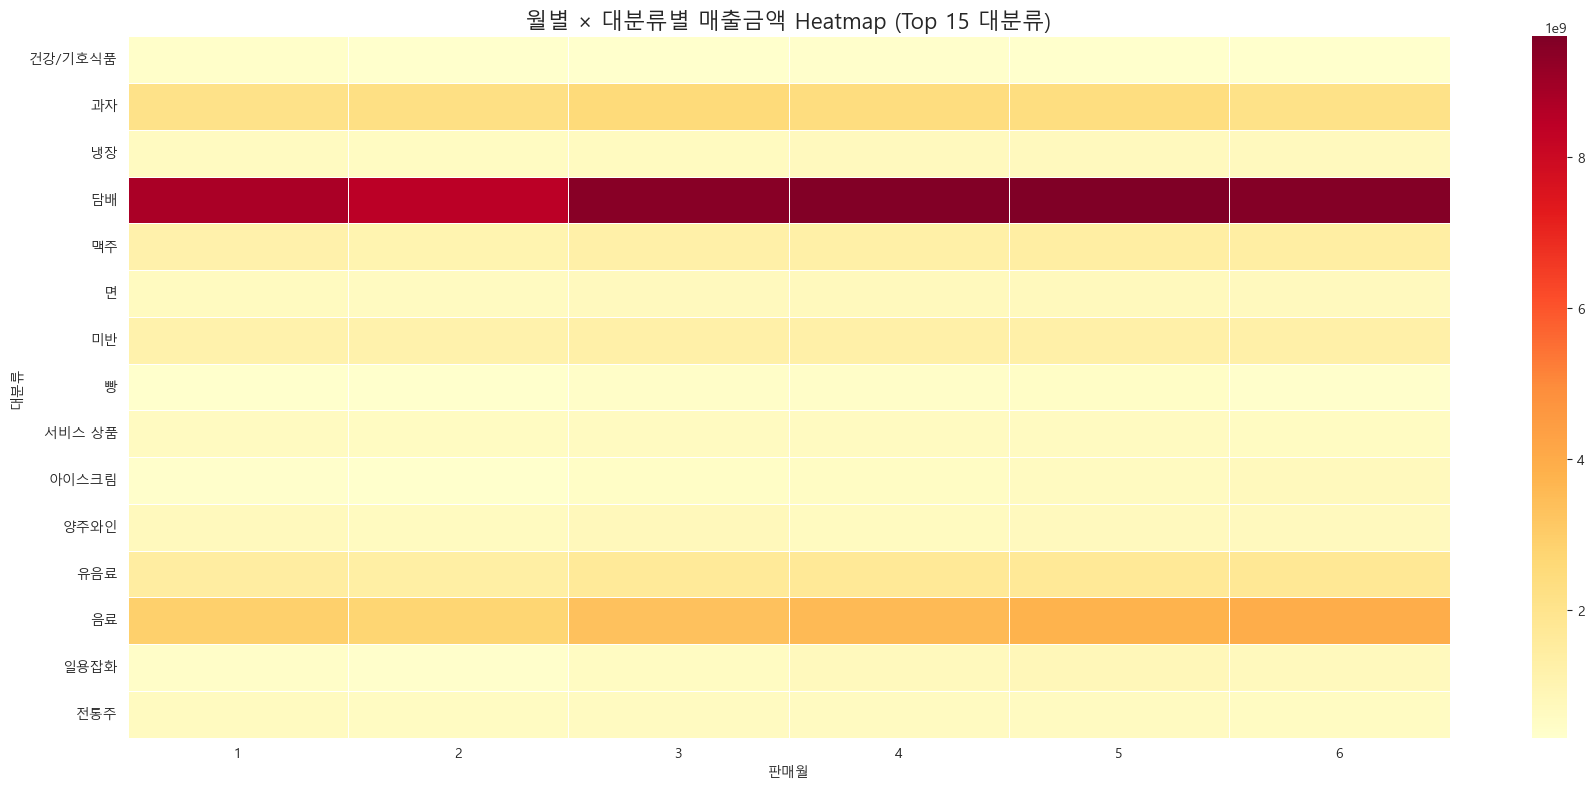

In [35]:
# 월 × 대분류 매출 Heatmap
if '상품대분류명' in df.columns:
    # 상위 15개 대분류만 선택
    top_cats = cat_sales.head(15).index.tolist()
    df_top = df[df['상품대분류명'].isin(top_cats)]

    pivot_month_cat = df_top.groupby(['판매월', '상품대분류명'])['매출금액'].sum().unstack(fill_value=0)

    plt.figure(figsize=(18, 8))
    sns.heatmap(pivot_month_cat.T, fmt='.0f', annot=False, cmap='YlOrRd', linewidths=0.5)
    plt.title('월별 × 대분류별 매출금액 Heatmap (Top 15 대분류)', fontsize=16)
    plt.xlabel('판매월')
    plt.ylabel('대분류')
    plt.tight_layout()
    plt.show()

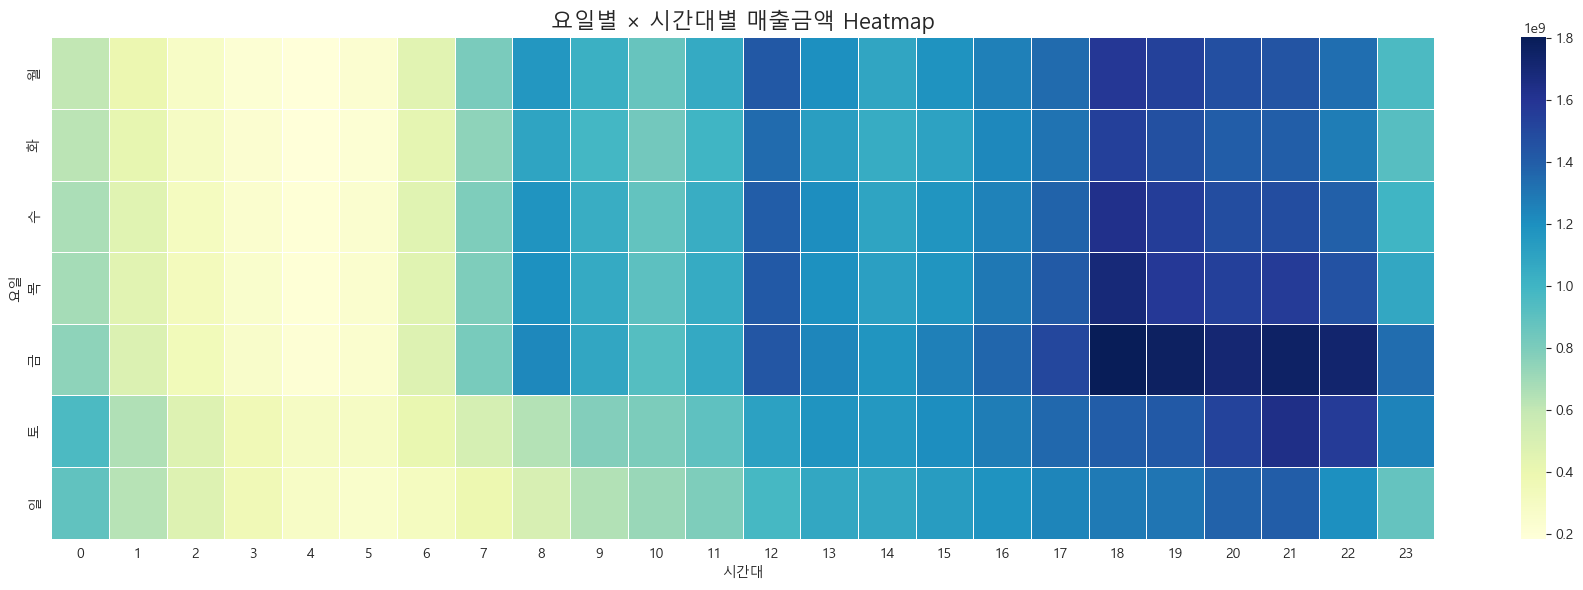

In [36]:
# 요일 × 시간대 매출 Heatmap
pivot_day_hour = df.groupby(['판매요일', '판매시간대'])['매출금액'].sum().unstack(fill_value=0)
pivot_day_hour.index = pivot_day_hour.index.map(요일이름)

plt.figure(figsize=(18, 6))
sns.heatmap(pivot_day_hour, annot=False, cmap='YlGnBu', linewidths=0.5)
plt.title('요일별 × 시간대별 매출금액 Heatmap', fontsize=16)
plt.xlabel('시간대')
plt.ylabel('요일')
plt.tight_layout()
plt.show()

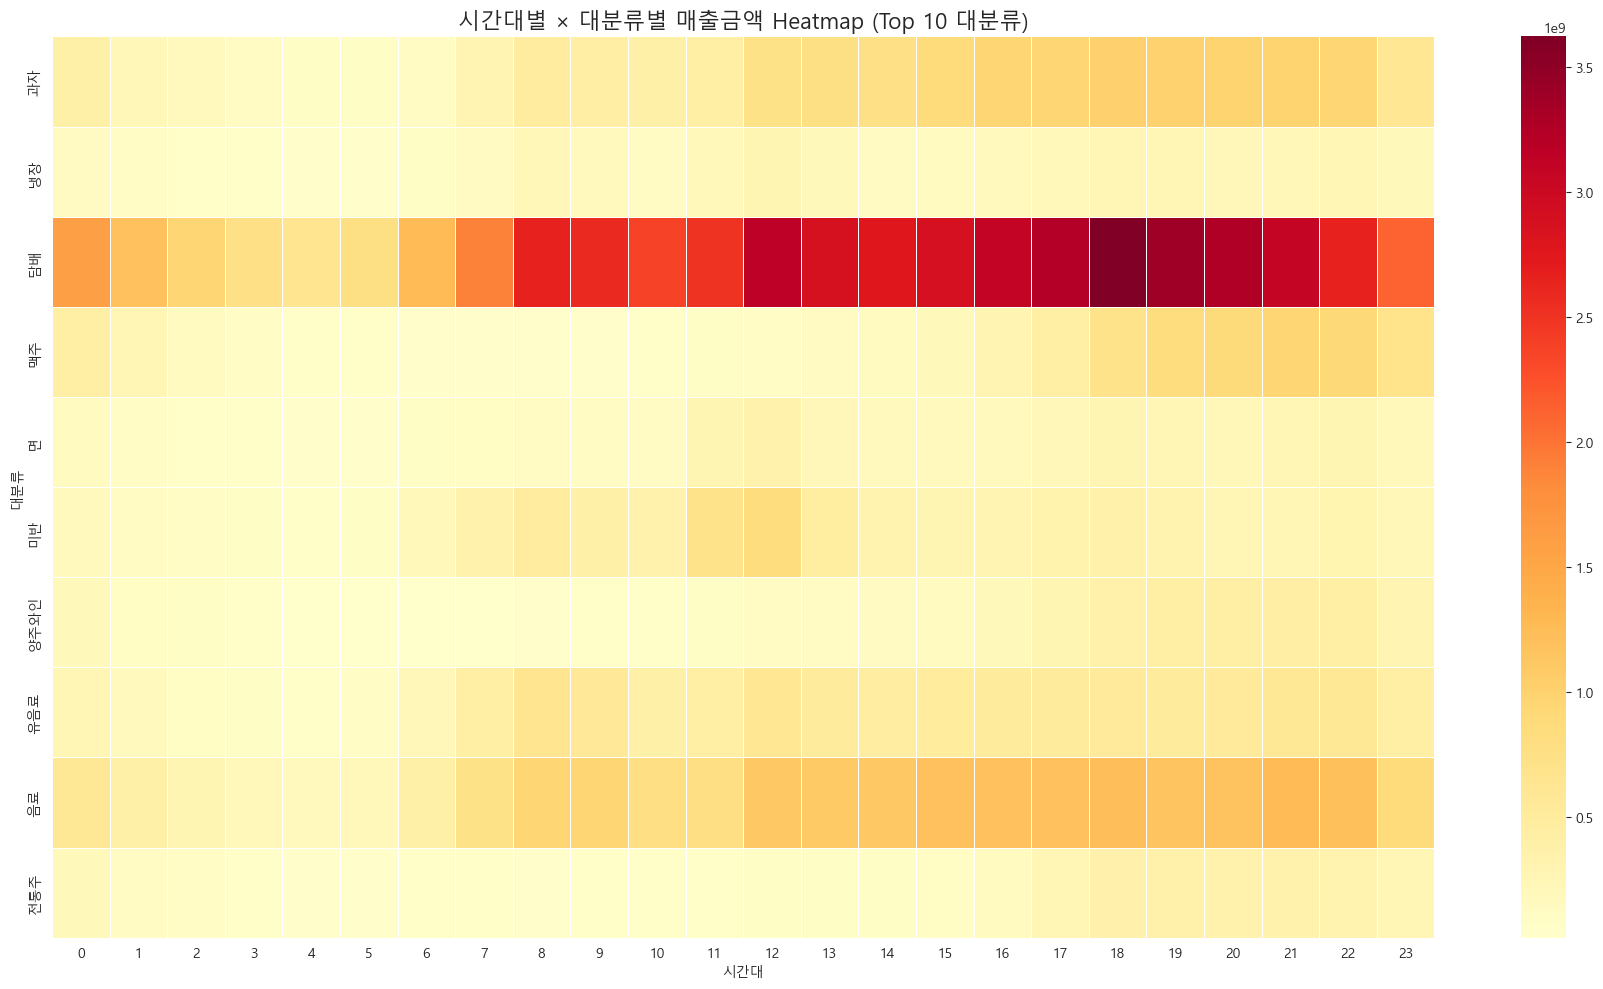

In [37]:
# 시간대 × 대분류 매출 Heatmap (상위 10개 대분류)
if '상품대분류명' in df.columns:
    top10_cats = cat_sales.head(10).index.tolist()
    df_top10 = df[df['상품대분류명'].isin(top10_cats)]

    pivot_hour_cat = df_top10.groupby(['판매시간대', '상품대분류명'])['매출금액'].sum().unstack(fill_value=0)

    plt.figure(figsize=(18, 10))
    sns.heatmap(pivot_hour_cat.T, annot=False, cmap='YlOrRd', linewidths=0.5)
    plt.title('시간대별 × 대분류별 매출금액 Heatmap (Top 10 대분류)', fontsize=16)
    plt.xlabel('시간대')
    plt.ylabel('대분류')
    plt.tight_layout()
    plt.show()

## 11. 분류 체계 분석

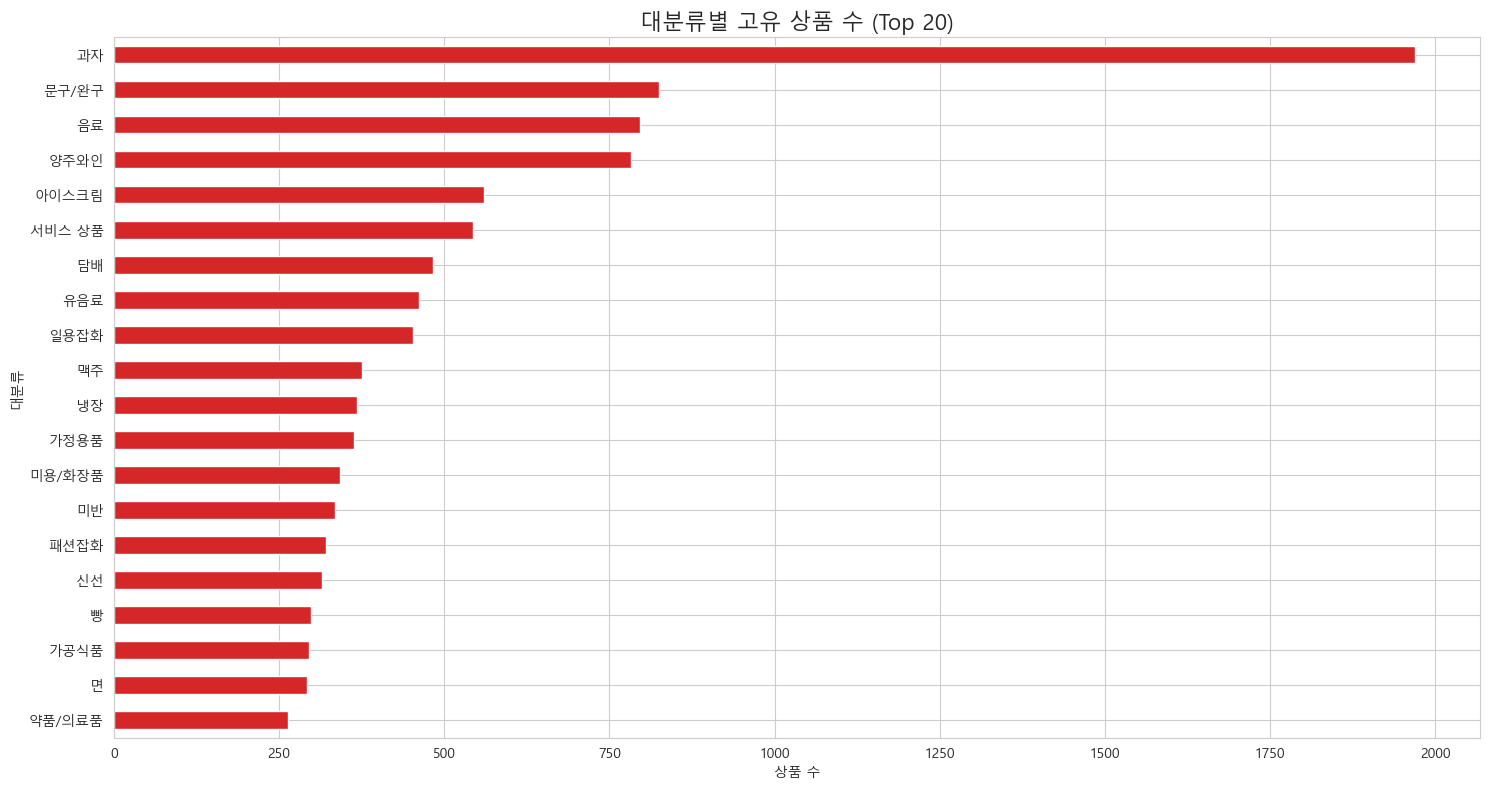


대분류 종류 수: 36
중분류 종류 수: 165
소분류 종류 수: 485


In [39]:
# 대분류별 상품 수
if '상품대분류명' in df.columns:
    lrdv_product_counts = df.groupby('상품대분류명')['상품코드'].nunique().sort_values(ascending=False)

    plt.figure(figsize=(15, 8))
    lrdv_product_counts.head(20).plot(kind='barh', color='#d62728')
    plt.title('대분류별 고유 상품 수 (Top 20)', fontsize=16)
    plt.xlabel('상품 수')
    plt.ylabel('대분류')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f'\n대분류 종류 수: {df["상품대분류명"].nunique()}')
    if '상품중분류명' in df.columns:
        print(f'중분류 종류 수: {df["상품중분류명"].nunique()}')
    if '상품소분류명' in df.columns:
        print(f'소분류 종류 수: {df["상품소분류명"].nunique()}')

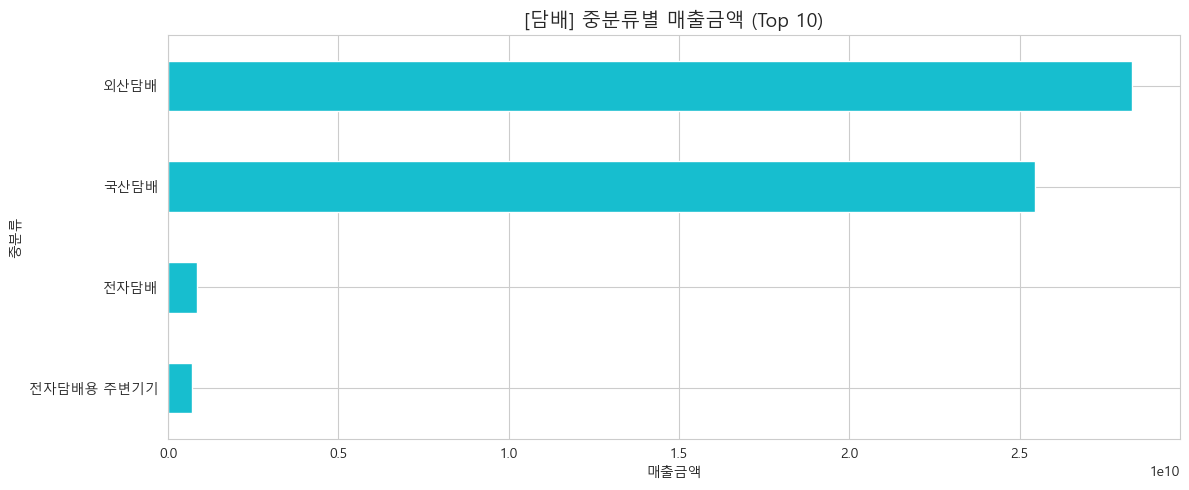

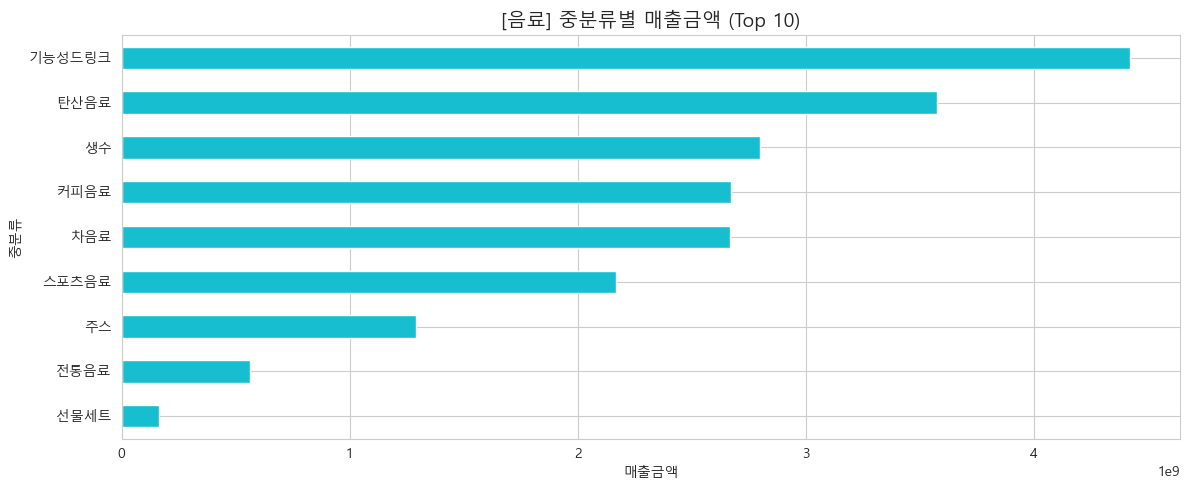

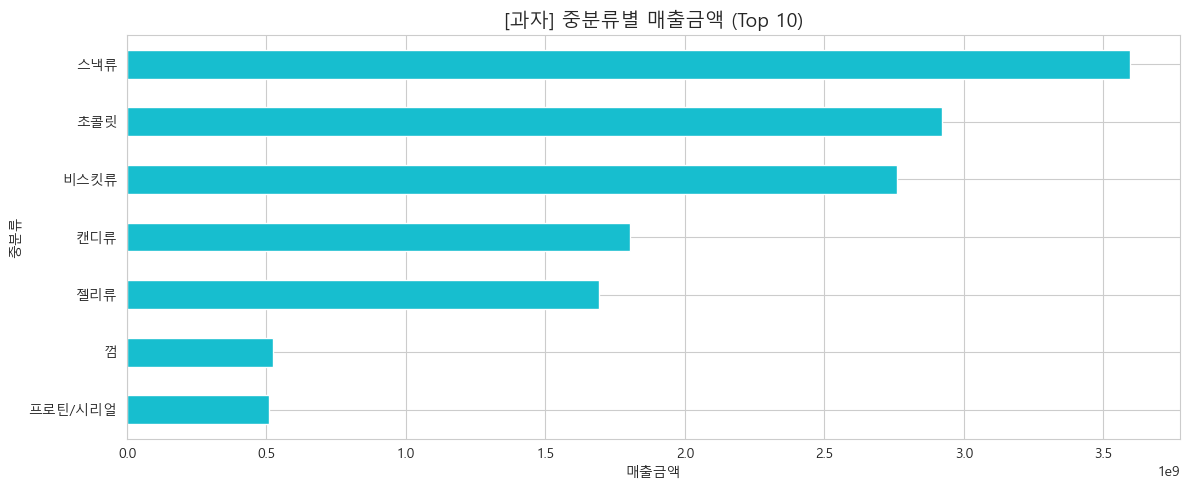

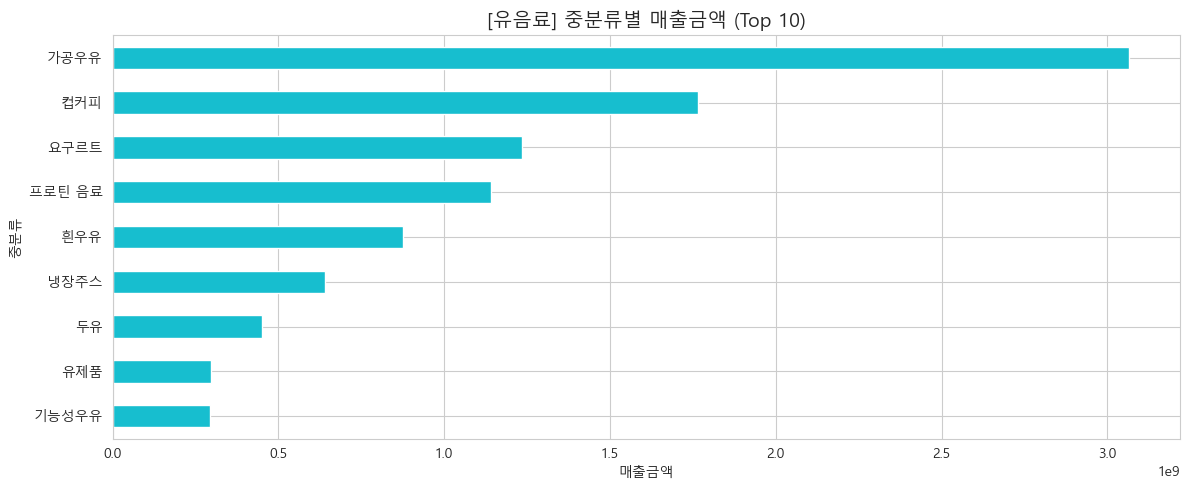

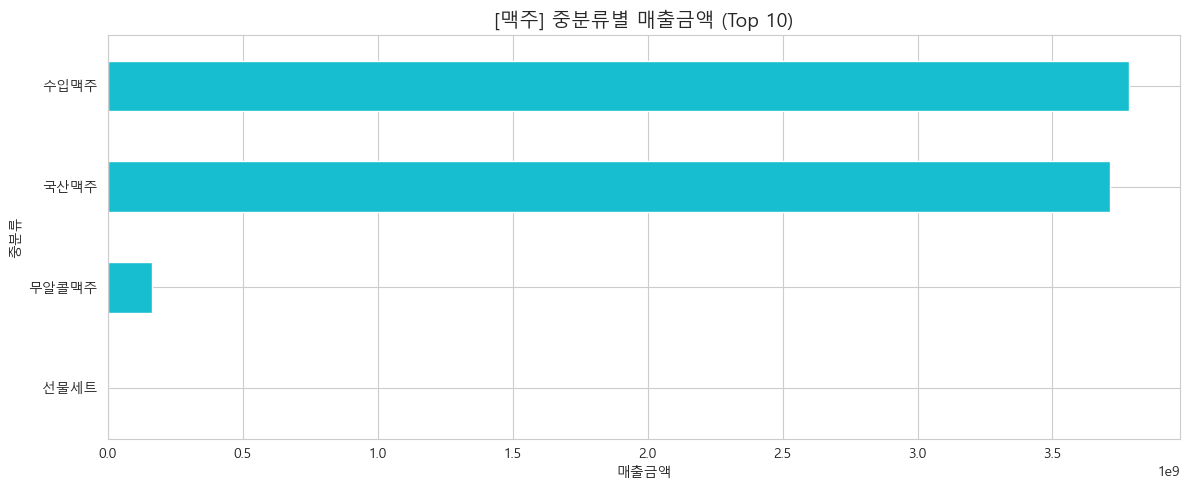

In [40]:
# 대분류 → 중분류 계층 분석 (상위 5개 대분류)
if '상품대분류명' in df.columns and '상품중분류명' in df.columns:
    top5_cats = cat_sales.head(5).index.tolist()

    for cat in top5_cats:
        sub_df = df[df['상품대분류명'] == cat]
        mid_sales = sub_df.groupby('상품중분류명')['매출금액'].sum().sort_values(ascending=False).head(10)

        plt.figure(figsize=(12, 5))
        mid_sales.plot(kind='barh', color='#17becf')
        plt.title(f'[{cat}] 중분류별 매출금액 (Top 10)', fontsize=14)
        plt.xlabel('매출금액')
        plt.ylabel('중분류')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

## 12. 주요 인사이트 요약

위의 EDA 결과를 바탕으로 아래 질문에 대한 답을 정리해 보세요:

1. **시간적 패턴**: 매출이 가장 높은 날짜/시간대/요일은 언제인가?
2. **점포 이질성**: 점포별 매출 편차(고매출점 vs 저매출점)가 얼마나 큰가?
3. **카테고리 기여도**: 전체 매출에서 각 대분류의 비중은 어떻게 분포되는가?
4. **계절성/트렌드**: 특정 카테고리의 월별 매출 증감 패턴이 있는가?
5. **반품/취소**: 음수 매출(약 2.1%)의 특성은 무엇인가? 특정 상품/점포/시간대에 집중되는가?
6. **미분류 상품**: B4에서 매핑되지 않는 상품코드의 매출 비중은?

# 📊 편의점 매출 데이터 분석 결과 보고서 (2025년 상반기)

---

## 1. 시간적 패턴: 매출 피크 및 요일별 특성
* **데이터 기간:** 2025년 1월 1일 ~ 2025년 6월 30일 (6개월)
* **전체 규모:** 총 매출금액 약 **1,625억 원** / 총 매출수량 약 **6,556만 개**
* **시간대별:** 매출 기준 피크 시간대는 **18시(약 109.3억)**이며, 이어서 21시, 19시, 20시 순입니다.
    > **Insight:** 18시~22시가 매출이 가장 집중되는 '골든타임'으로, 퇴근 및 귀가 시간대의 핵심 수요를 확인했습니다.
* **요일별:** 주중과 주말의 차이가 뚜렷하며, 일반적으로 **금~토요일**에 매출이 높고 **월~화요일**에 낮은 패턴을 보입니다.

---

## 2. 점포 이질성: 점포별 매출 편차
전체 **448개 점포**를 대상으로 분석한 결과, 점포 간 매출 격차가 매우 크게 나타났습니다.

| 항목 | 통계치 |
| :--- | :--- |
| **평균 매출** | 약 3.63억 원 |
| **표준편차** | 약 2.06억 원 (평균 대비 57%) |
| **최댓값** | 약 14.88억 원 |
| **중앙값(50%)** | 약 3.18억 원 |
| **최솟값** | 약 935만 원 |

* **핵심 인사이트:** 최고 매출 점포가 최저 매출 점포보다 **약 159배** 높은 극단적 격차가 존재합니다. 이는 입지 및 상권 특성에 따른 이질성이 매우 크다는 것을 시사하며, 하위 점포에 대한 개별 개선 전략이 필요합니다.

---

## 3. 카테고리 기여도: 주요 품목 비중
전체 36개 대분류 중 소수의 품목이 전체 매출을 견인하는 **파레토 분포**를 보입니다.

* **매출 상위 5대 분류:**
    1. 담배 (압도적 1위)
    2. 스낵/과자류
    3. 음료
    4. 주류 (전통주 포함)
    5. 도시락/간편식
* **기타:** 면, 냉장, 서비스 상품 등이 중위권을 형성하며 디저트나 H&B 등의 기여도는 상대적으로 낮습니다.

---

## 4. 계절성 및 트렌드 분석
겨울부터 초여름(1~6월)까지의 기간적 특성에 따른 매출 변화가 관찰됩니다.

* **아이스크림 & 음료:** 기온 상승에 따라 **4~6월**로 갈수록 매출이 급증하는 패턴을 보입니다.
* **라면(면):** 상대적으로 추운 **1~2월**에 높은 매출을 보이다가 기온 상승 시 소폭 감소하는 경향이 있습니다.
* **향후 분석:** 카테고리별 월별 히트맵 분석을 통해 정밀한 수요 예측이 가능할 것으로 보입니다.

---

## 5. 반품 및 취소: 음수 매출 분석
* **발생 건수:** 1,056,894건 (전체 거래의 약 **2.12%**)
* **통계적 특성:** 75% 이상의 데이터가 **-1개**로 일반적인 반품 건입니다.
* **이상값(Outlier):** 최솟값이 **-2,000개**인 사례가 발견되었습니다.
    > **Insight:** 이는 단순 반품이 아닌 대량 입고 오류나 재고 조정일 가능성이 높으므로, 특정 점포나 상품에 집중되는지 추가 검증이 필요합니다.

---

## 6. 데이터 무결성: 미분류 상품 매핑
* **미매핑 수:** 0건 (**0.00%**)
* **핵심 인사이트:** POS 데이터(B2)와 상품분류 데이터(B4)가 **100% 정상 매핑**되었습니다. 카테고리 기반 분석 결과의 신뢰도가 매우 높음을 의미합니다.

In [41]:
# 최종 요약 통계
print('='*60)
print('EDA 요약 통계')
print('='*60)
print(f'전체 행 수: {len(df):,}')
print(f'고유 점포 수: {df["점포코드"].nunique():,}')
print(f'고유 상품 수: {df["상품코드"].nunique():,}')
print(f'총 매출금액: {df["매출금액"].sum():,}')
print(f'총 매출수량: {df["매출수량"].sum():,}')
if '상품대분류명' in df.columns:
    print(f'대분류 수: {df["상품대분류명"].nunique()}')
    print(f'분류 미매핑 비율: {df["상품대분류명"].isna().mean()*100:.2f}%')
print(f'음수 매출 비율: {(df["매출수량"] < 0).mean()*100:.2f}%')
print(f'데이터 기간: {df["판매시간_dt"].min()} ~ {df["판매시간_dt"].max()}')
print('='*60)

EDA 요약 통계
전체 행 수: 49,757,758
고유 점포 수: 448
고유 상품 수: 12,602
총 매출금액: 162,490,875,387
총 매출수량: 65,557,931
대분류 수: 36
분류 미매핑 비율: 0.00%
음수 매출 비율: 2.12%
데이터 기간: 2025-01-01 00:00:01 ~ 2025-06-30 23:59:58


## 13. 카테고리별 시계열 주기성 분석

상품대분류별로 판매월 / 판매주 / 판매요일 / 판매시간대에 따른 매출금액 추이를 분석하여, 
각 카테고리의 시간적 주기성(계절성, 주간·일간 패턴)을 파악합니다.

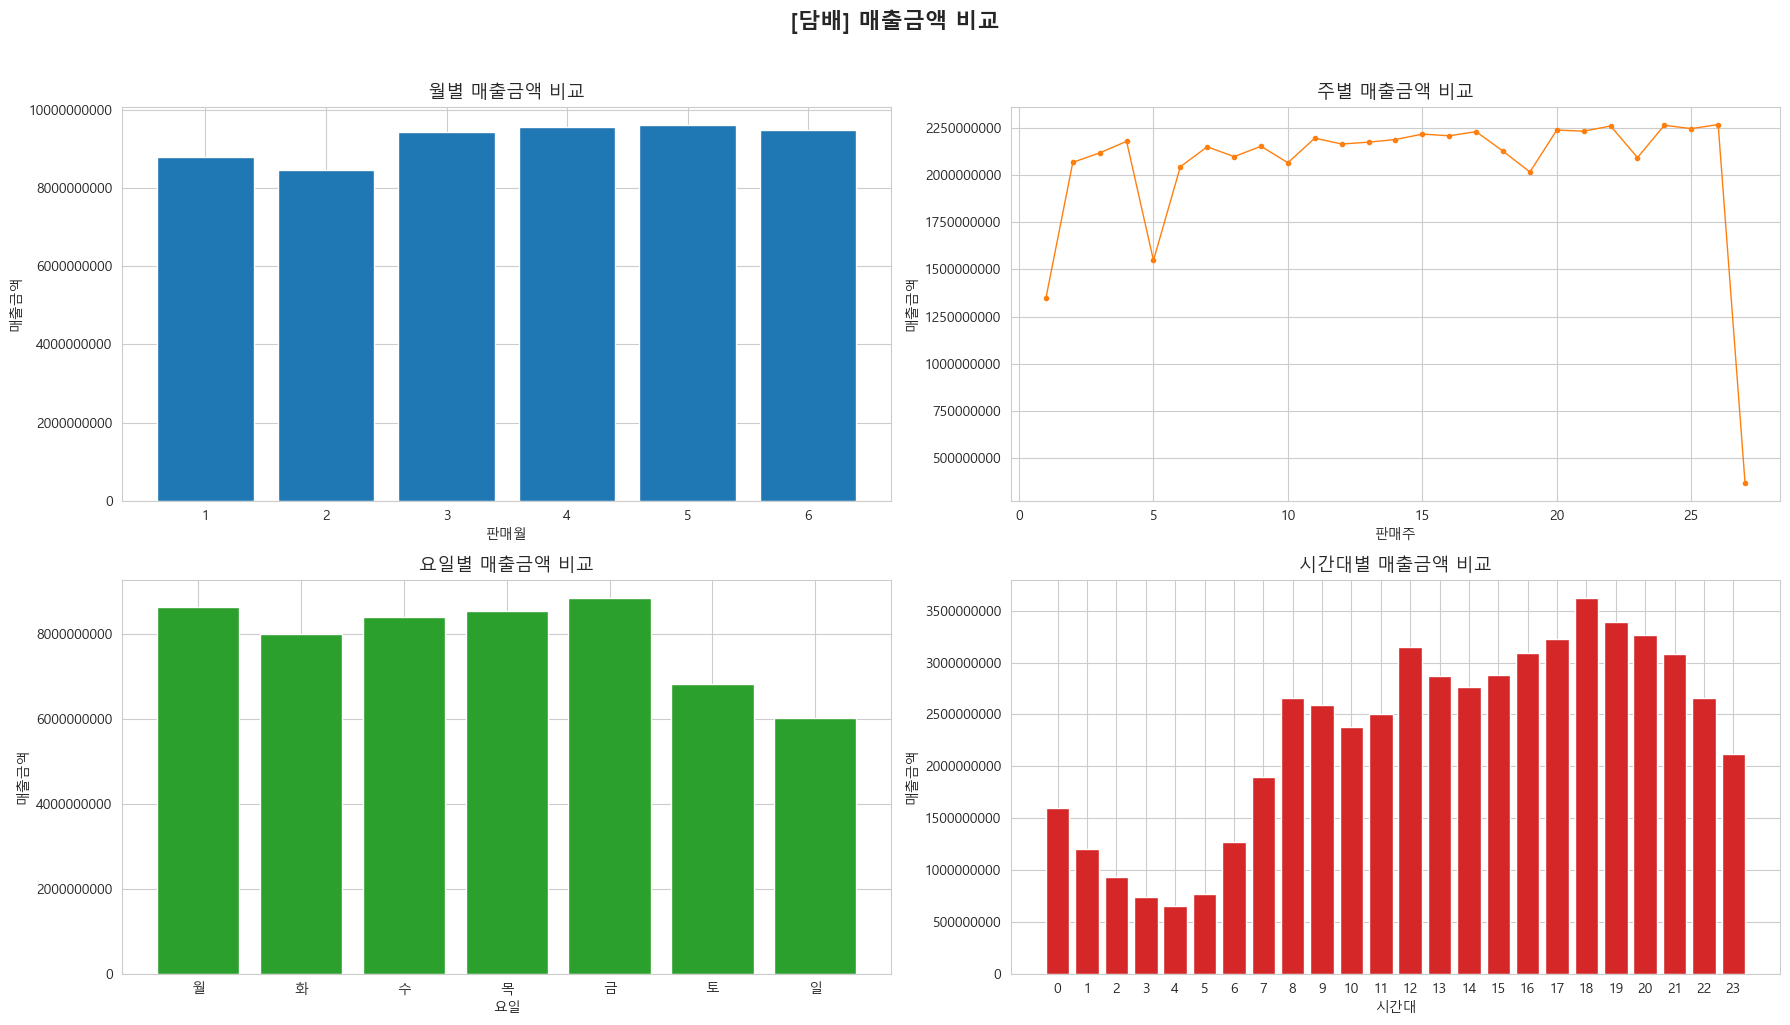

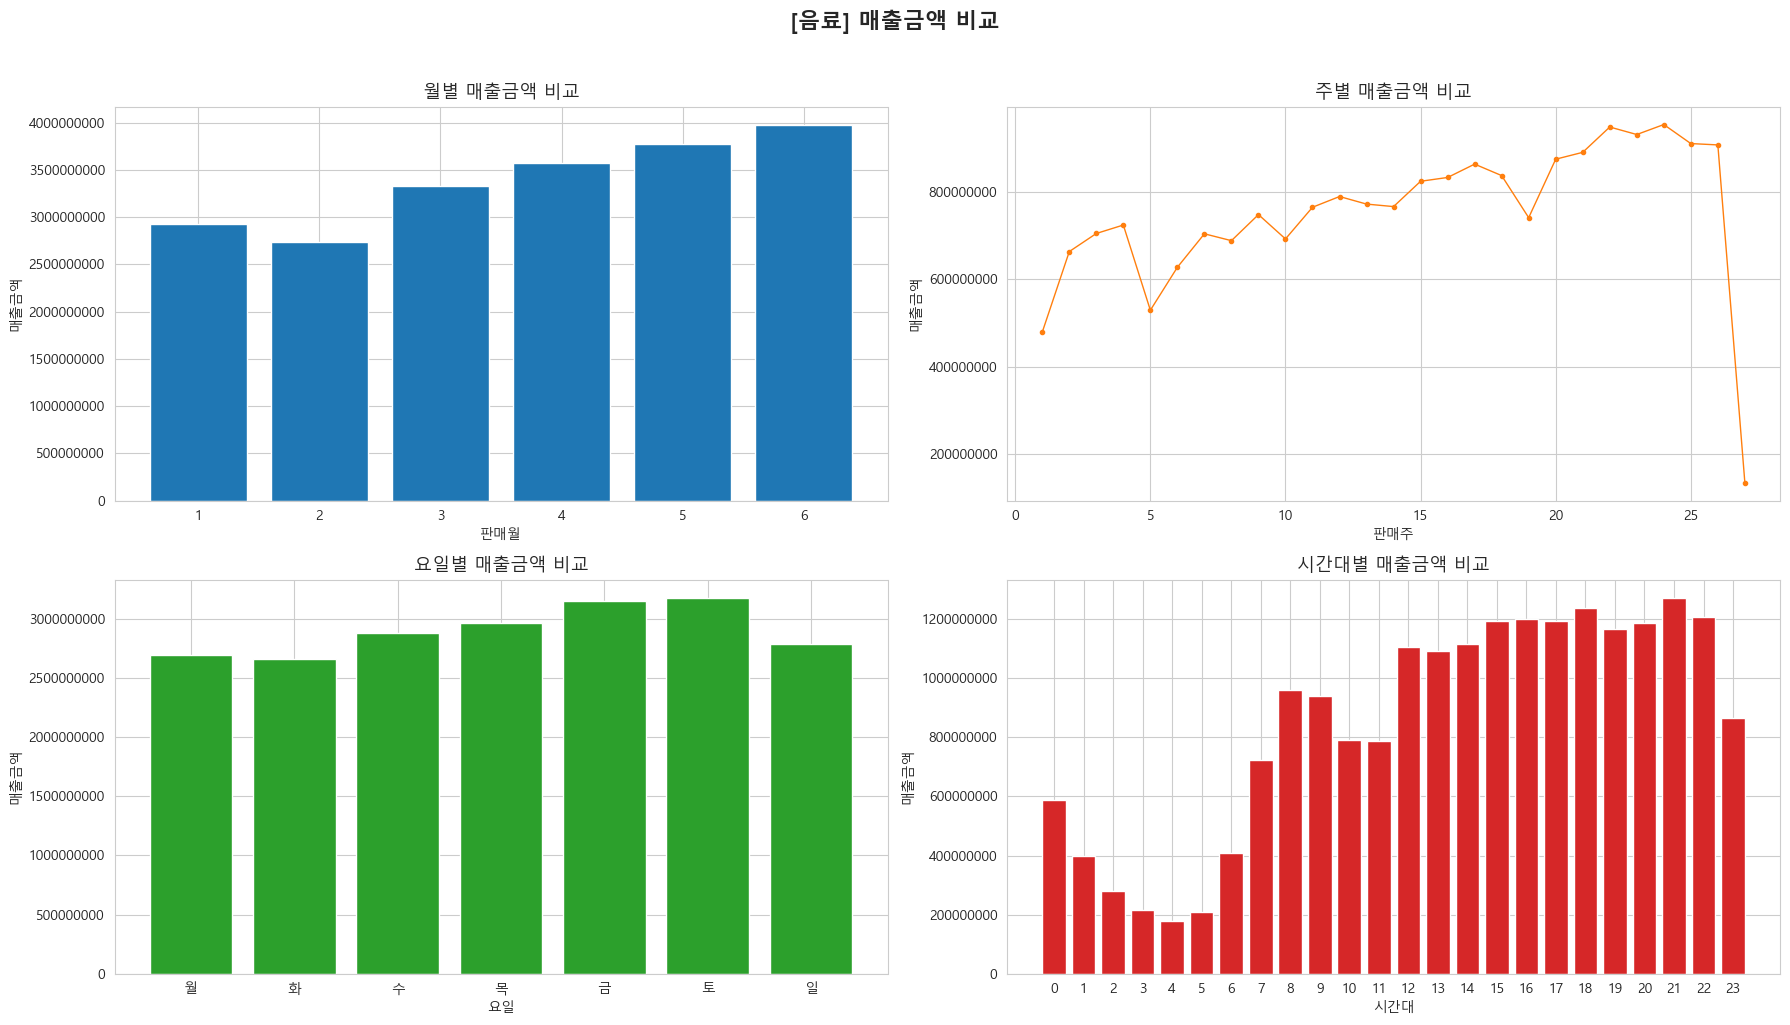

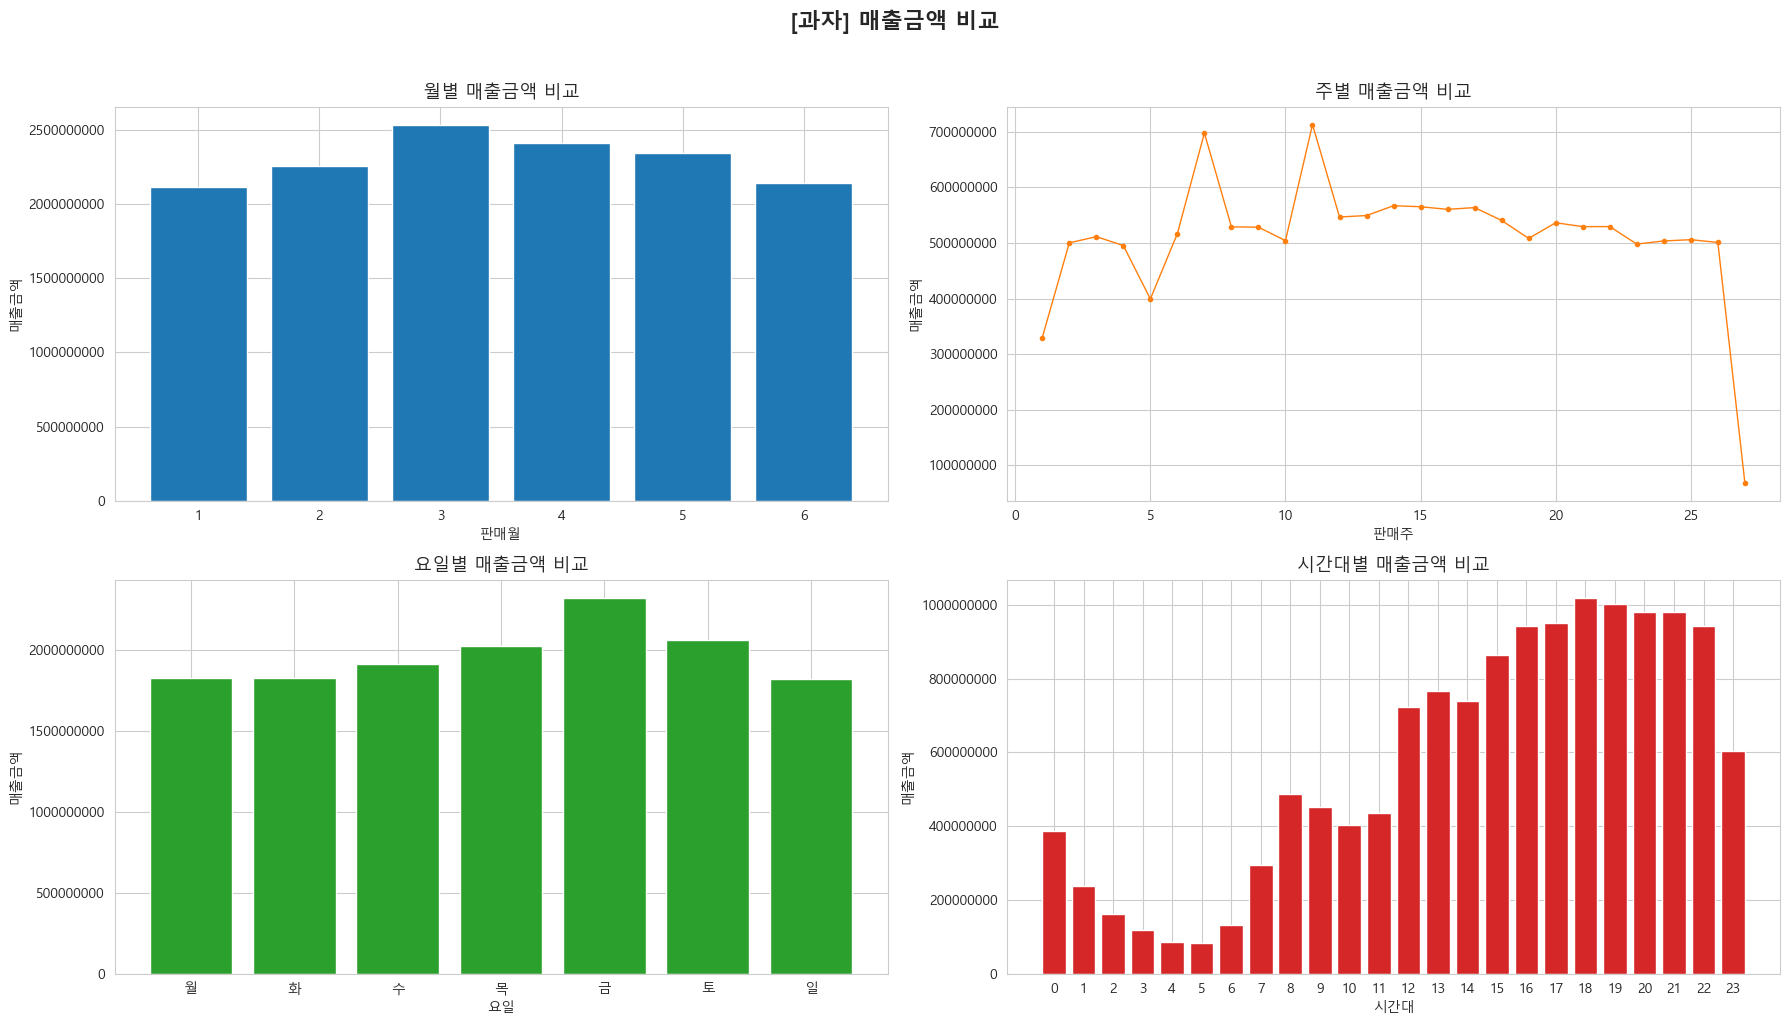

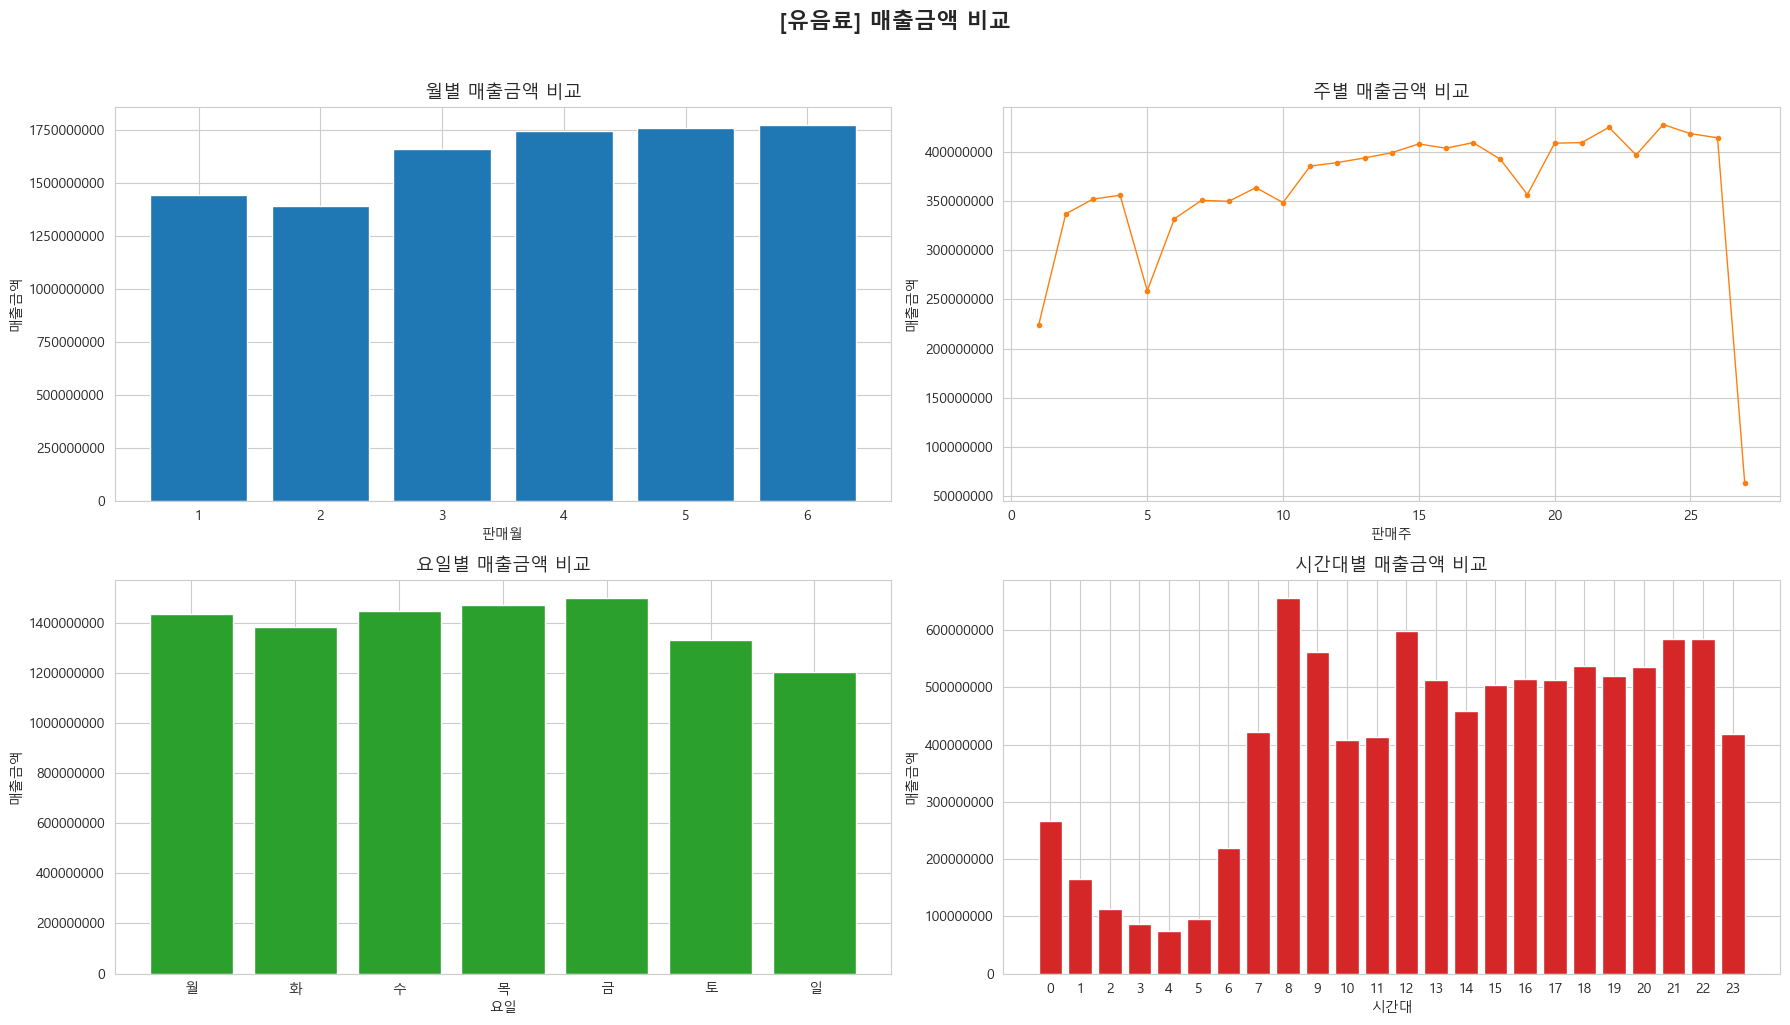

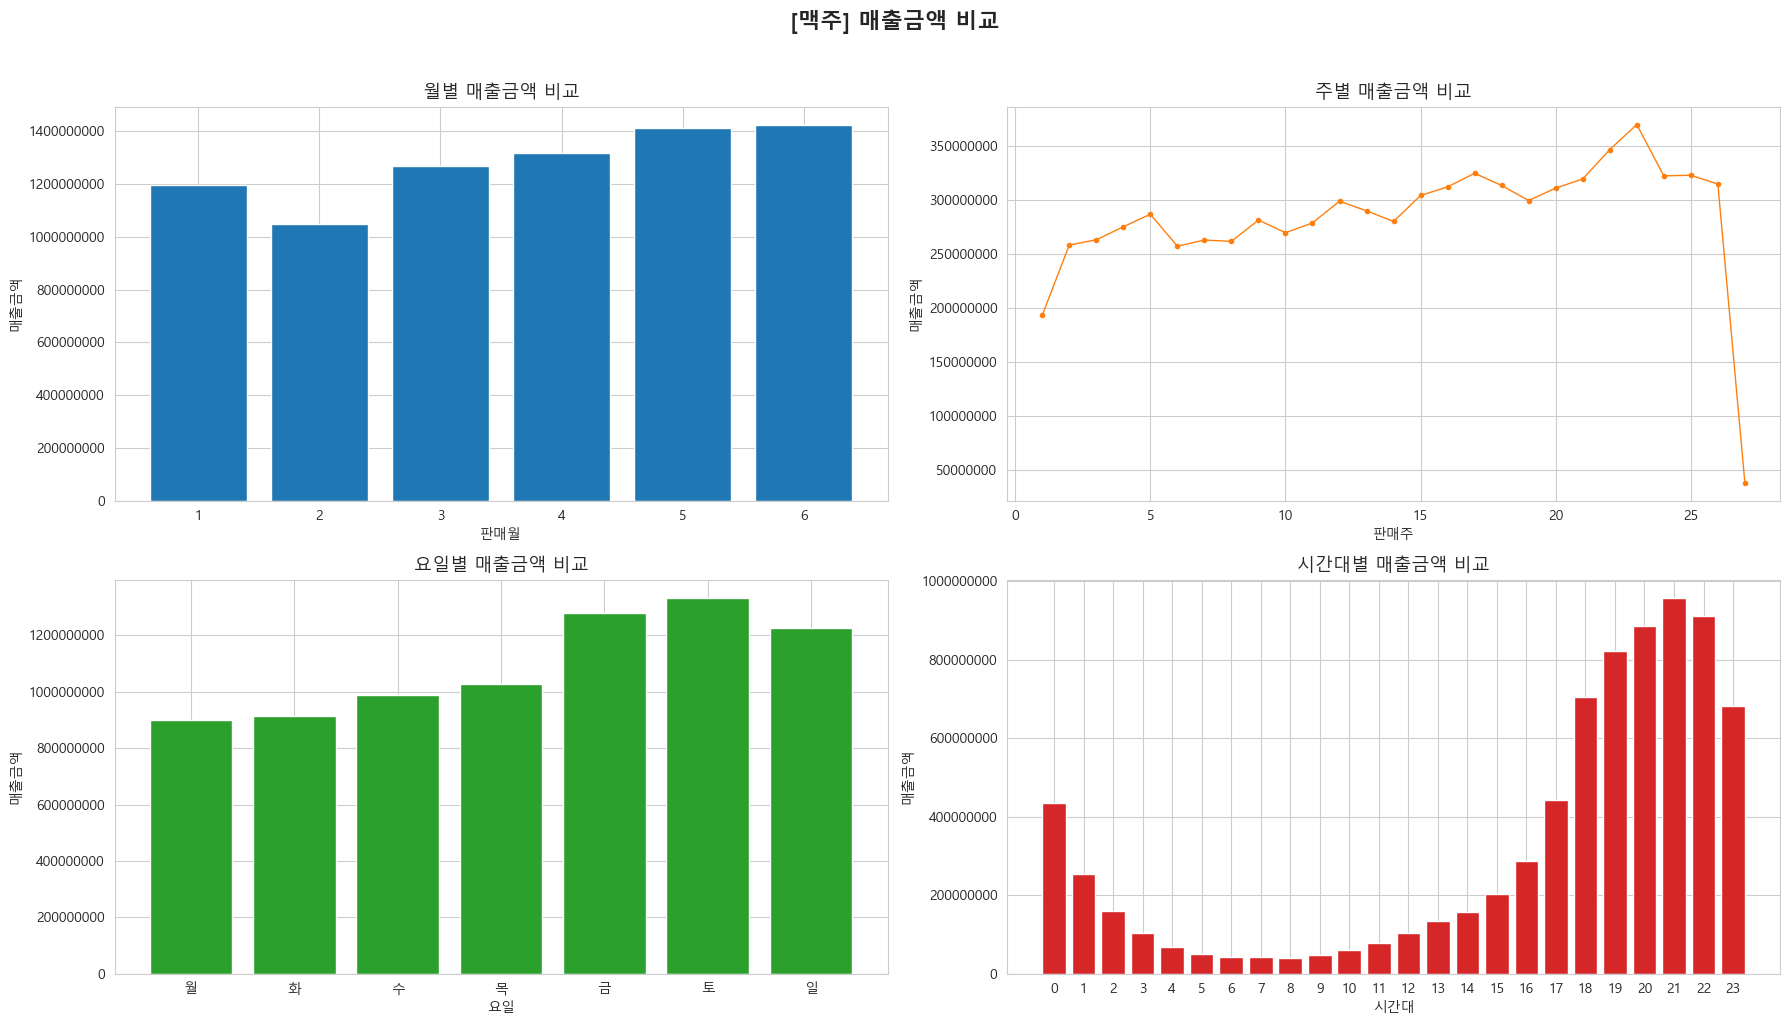

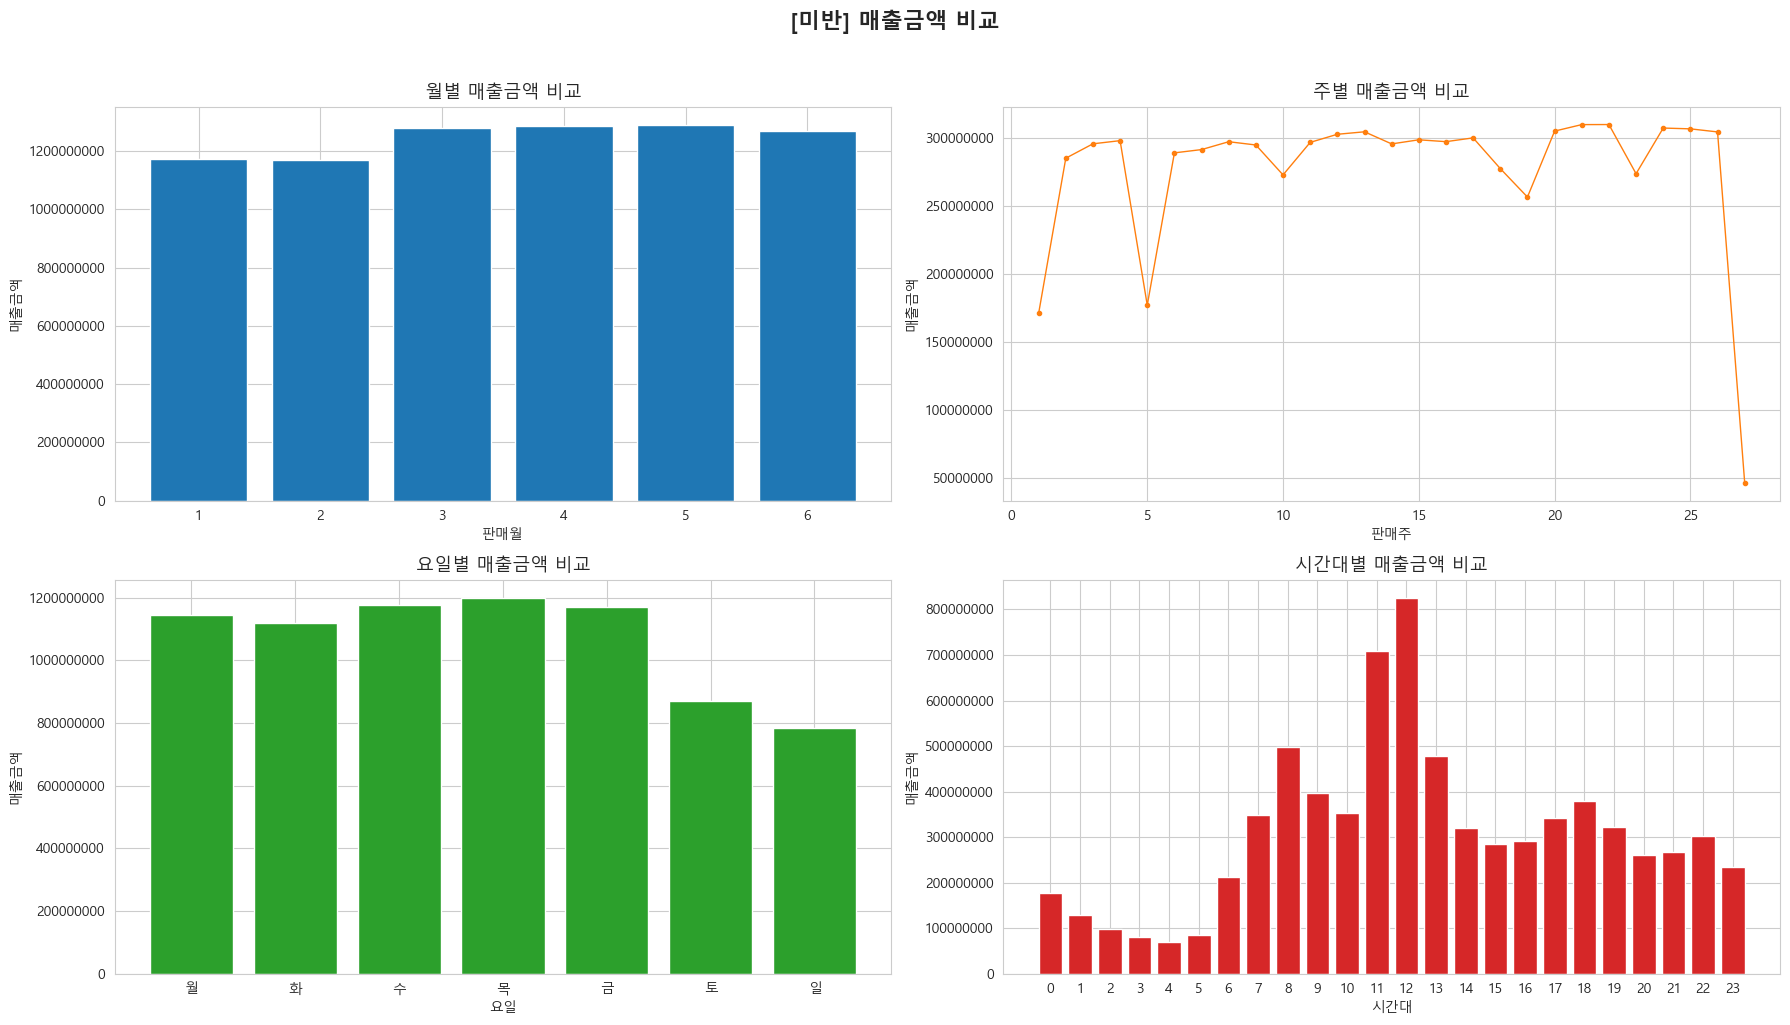

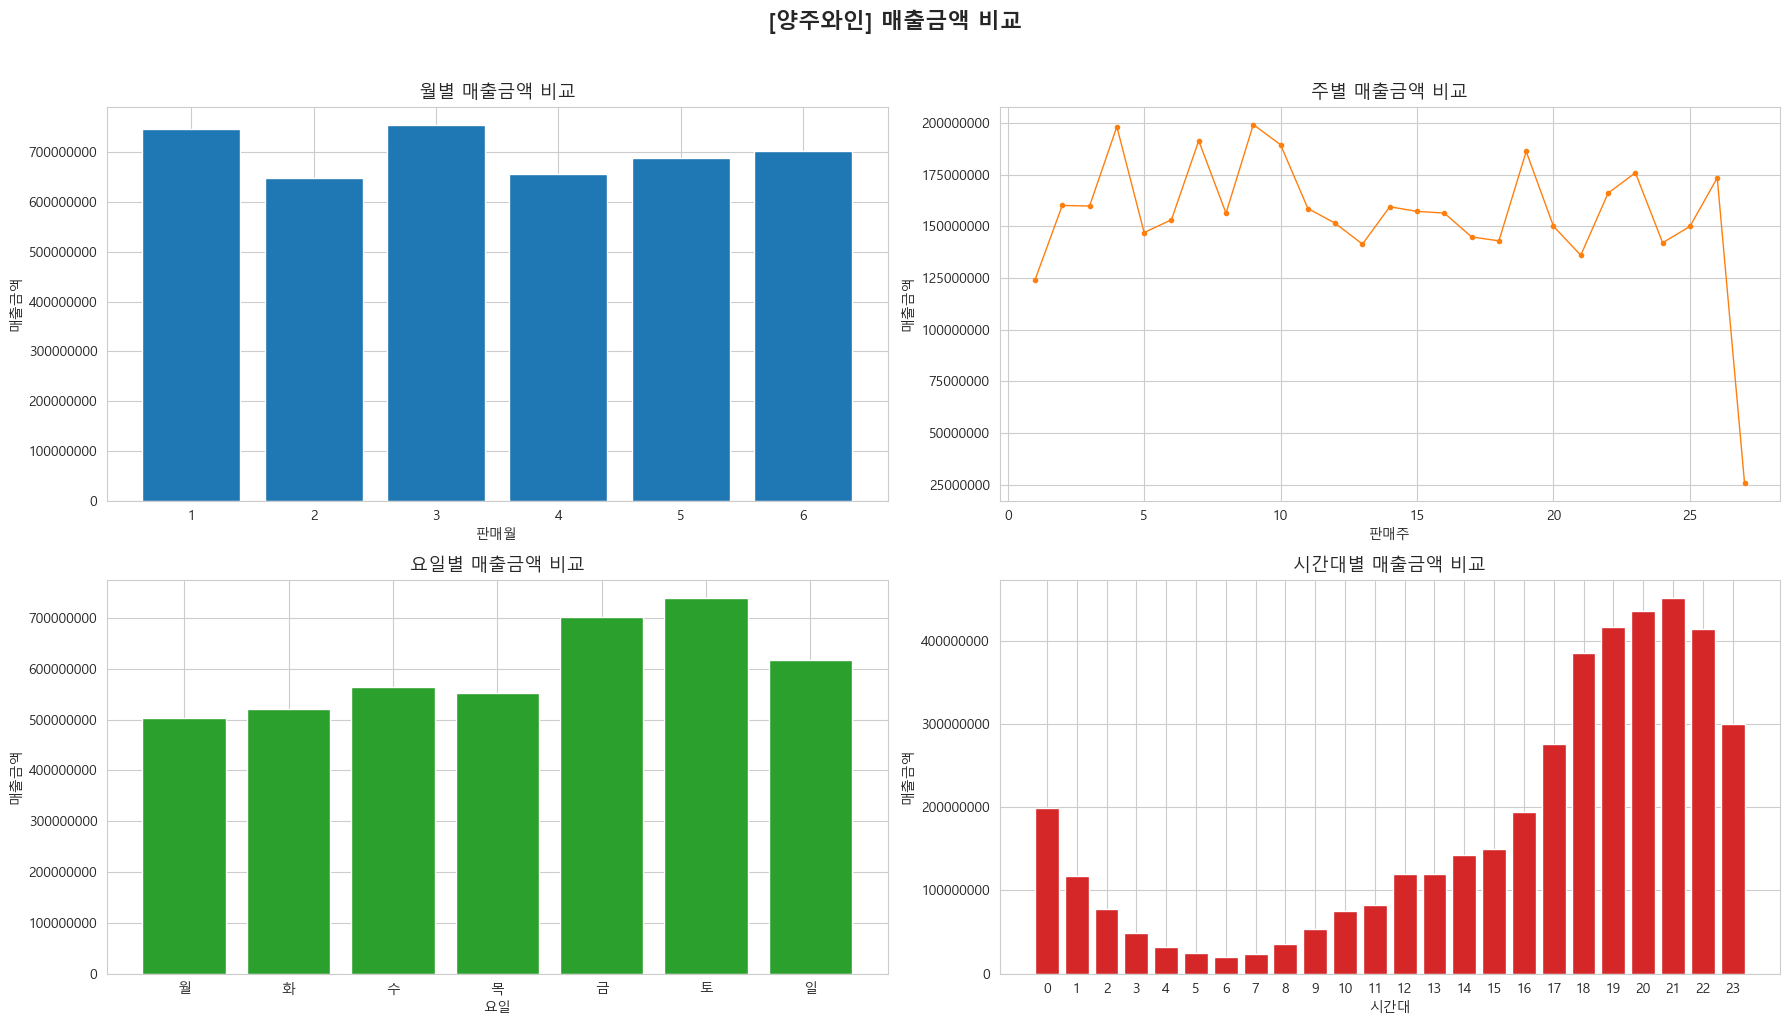

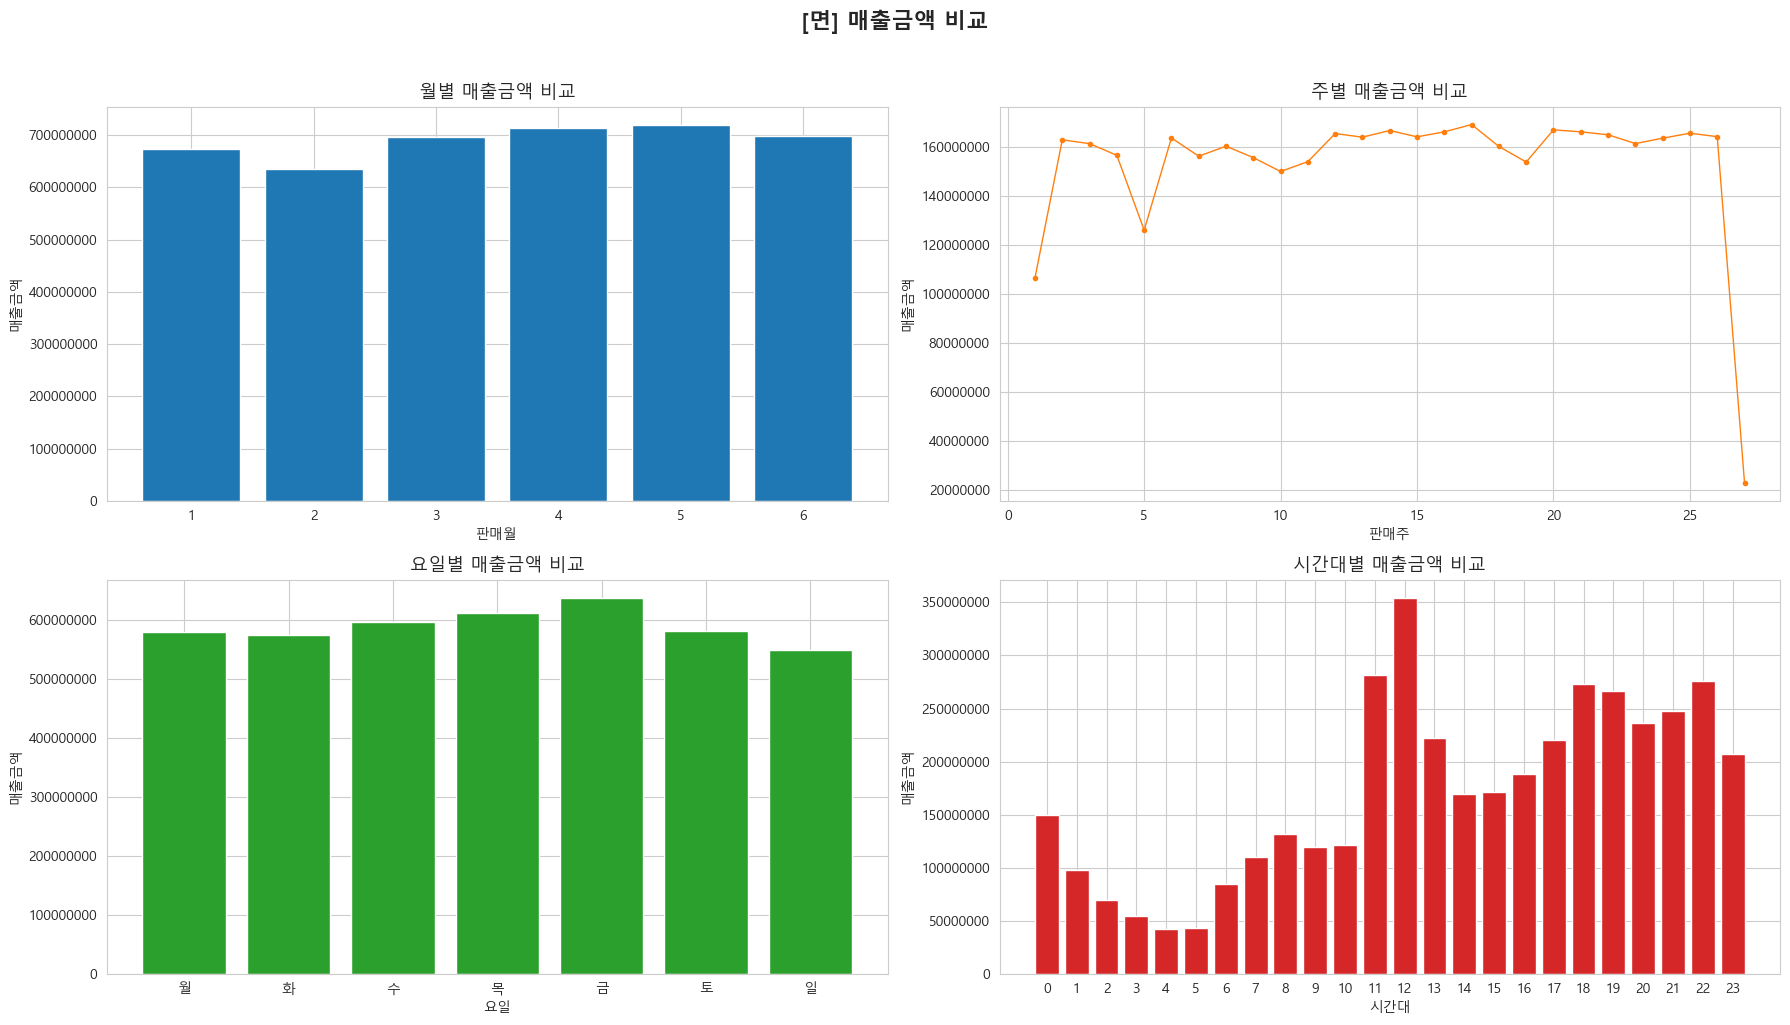

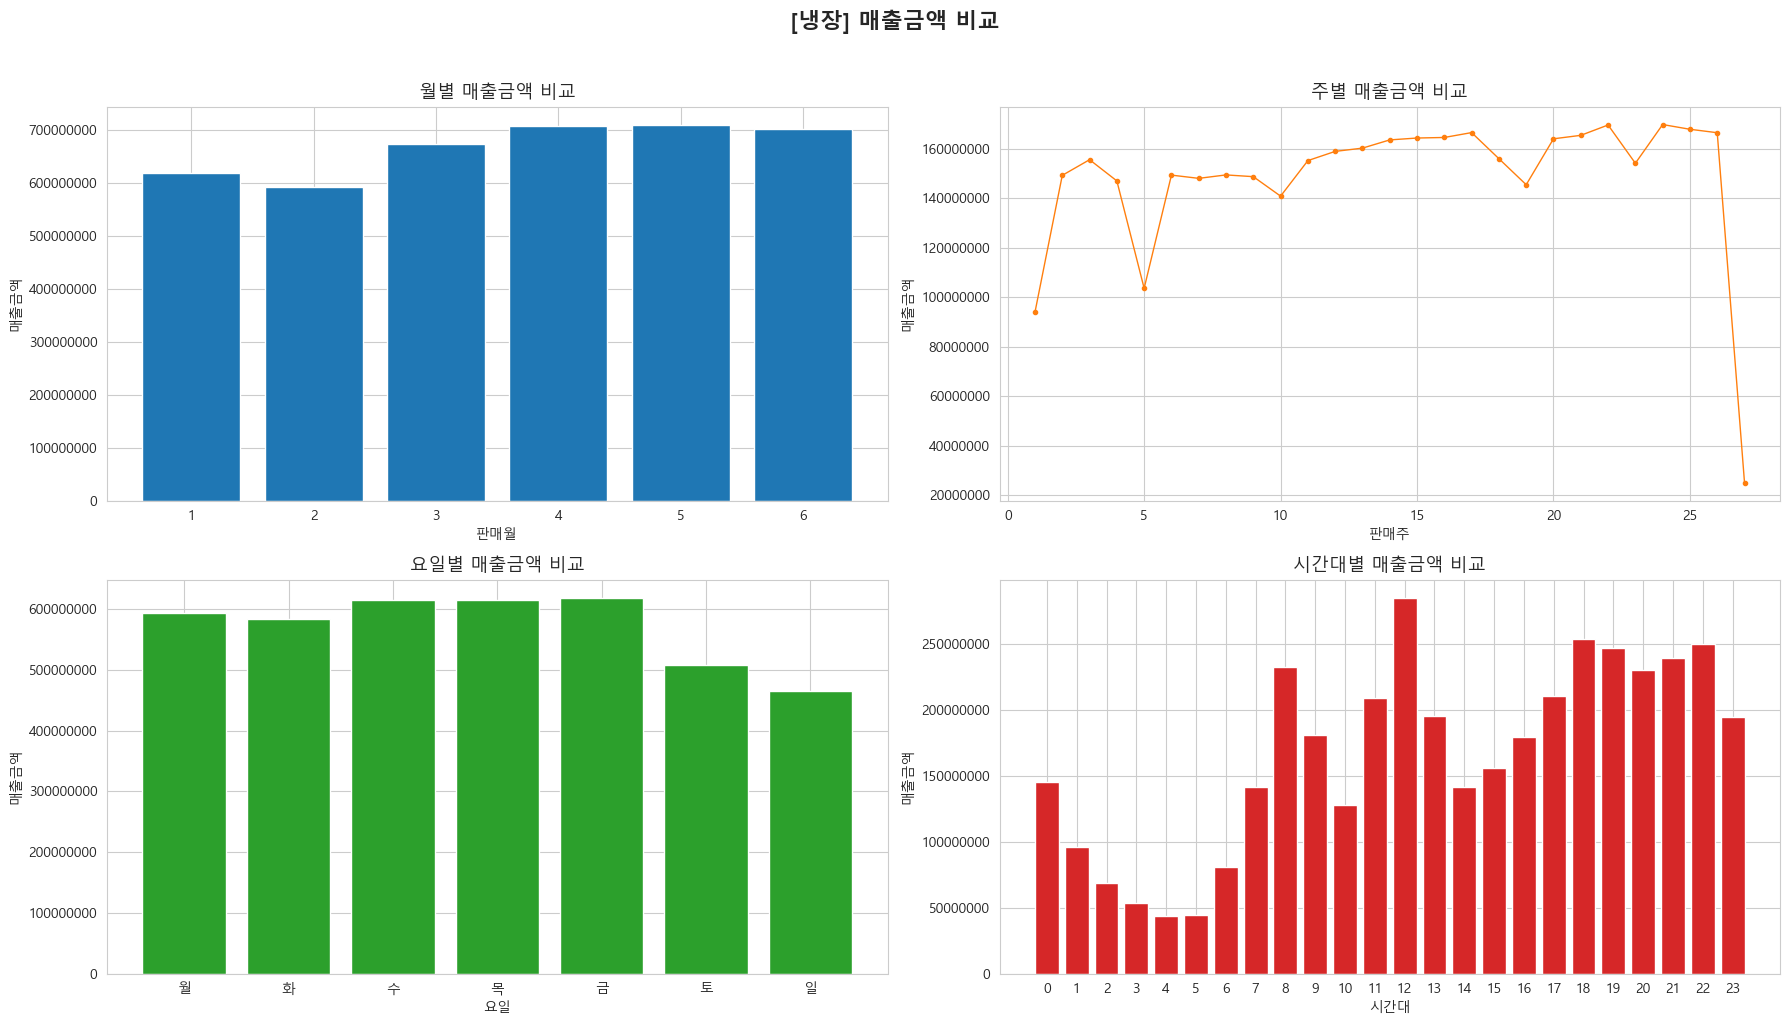

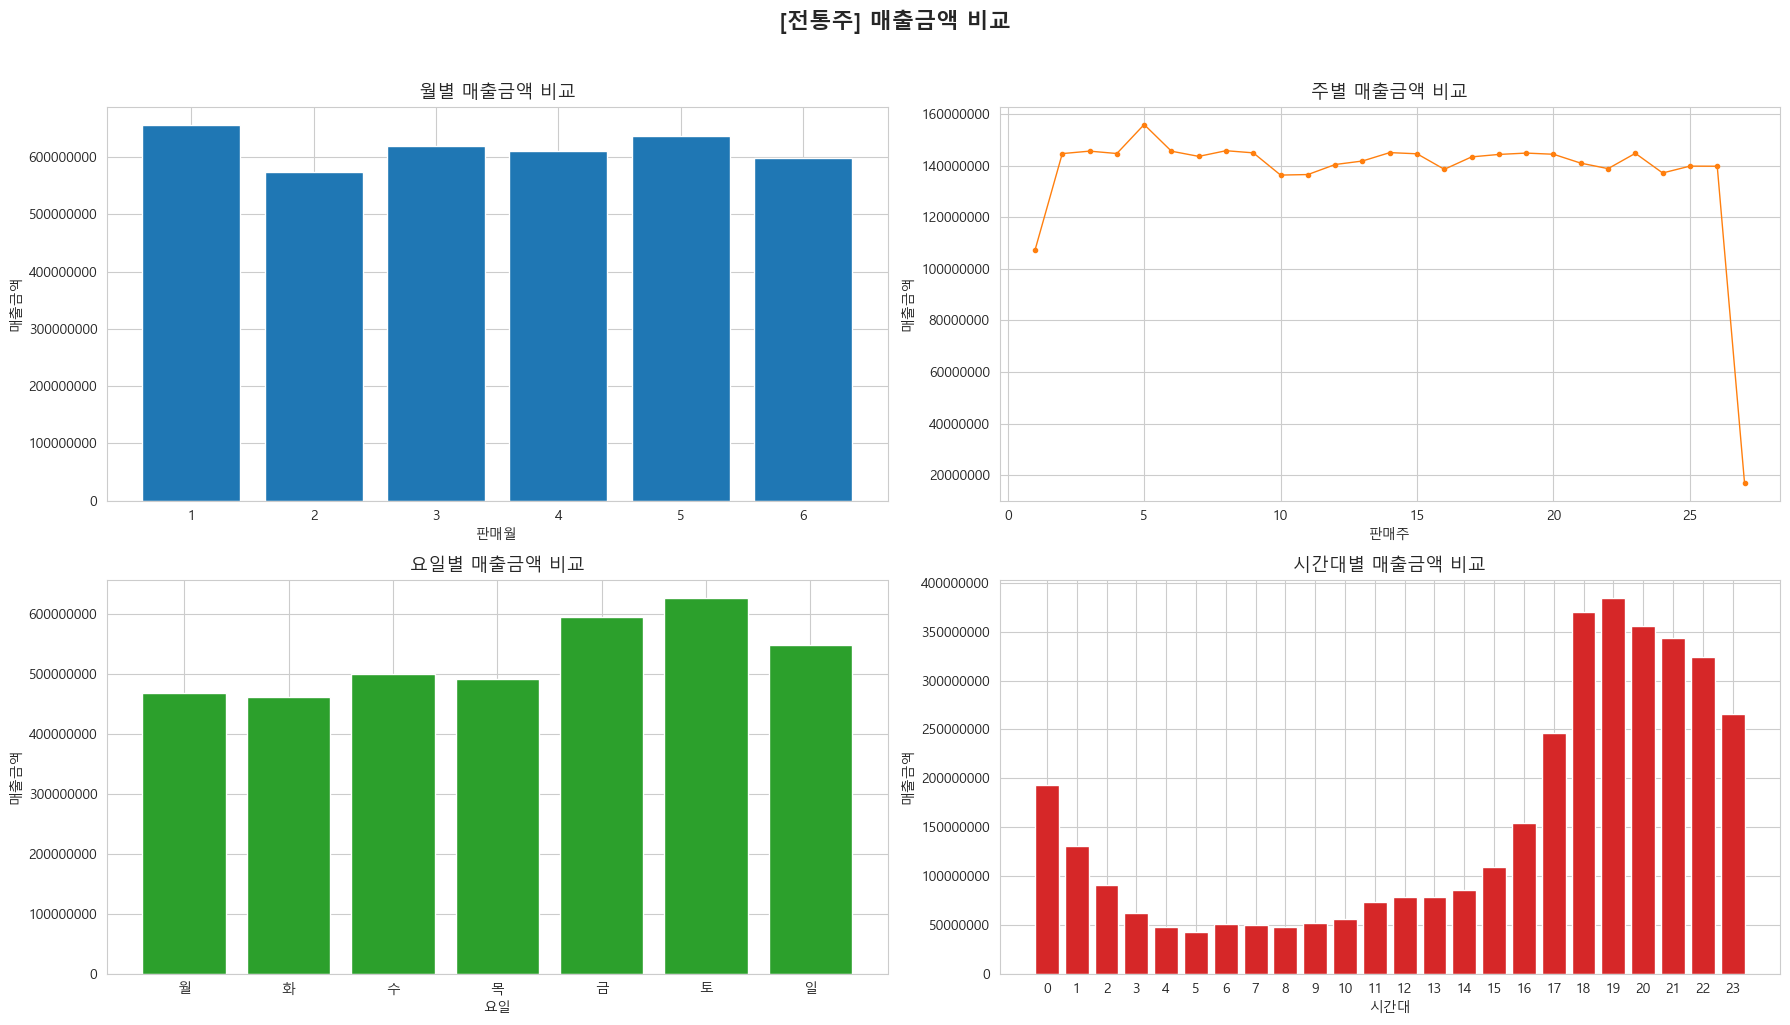

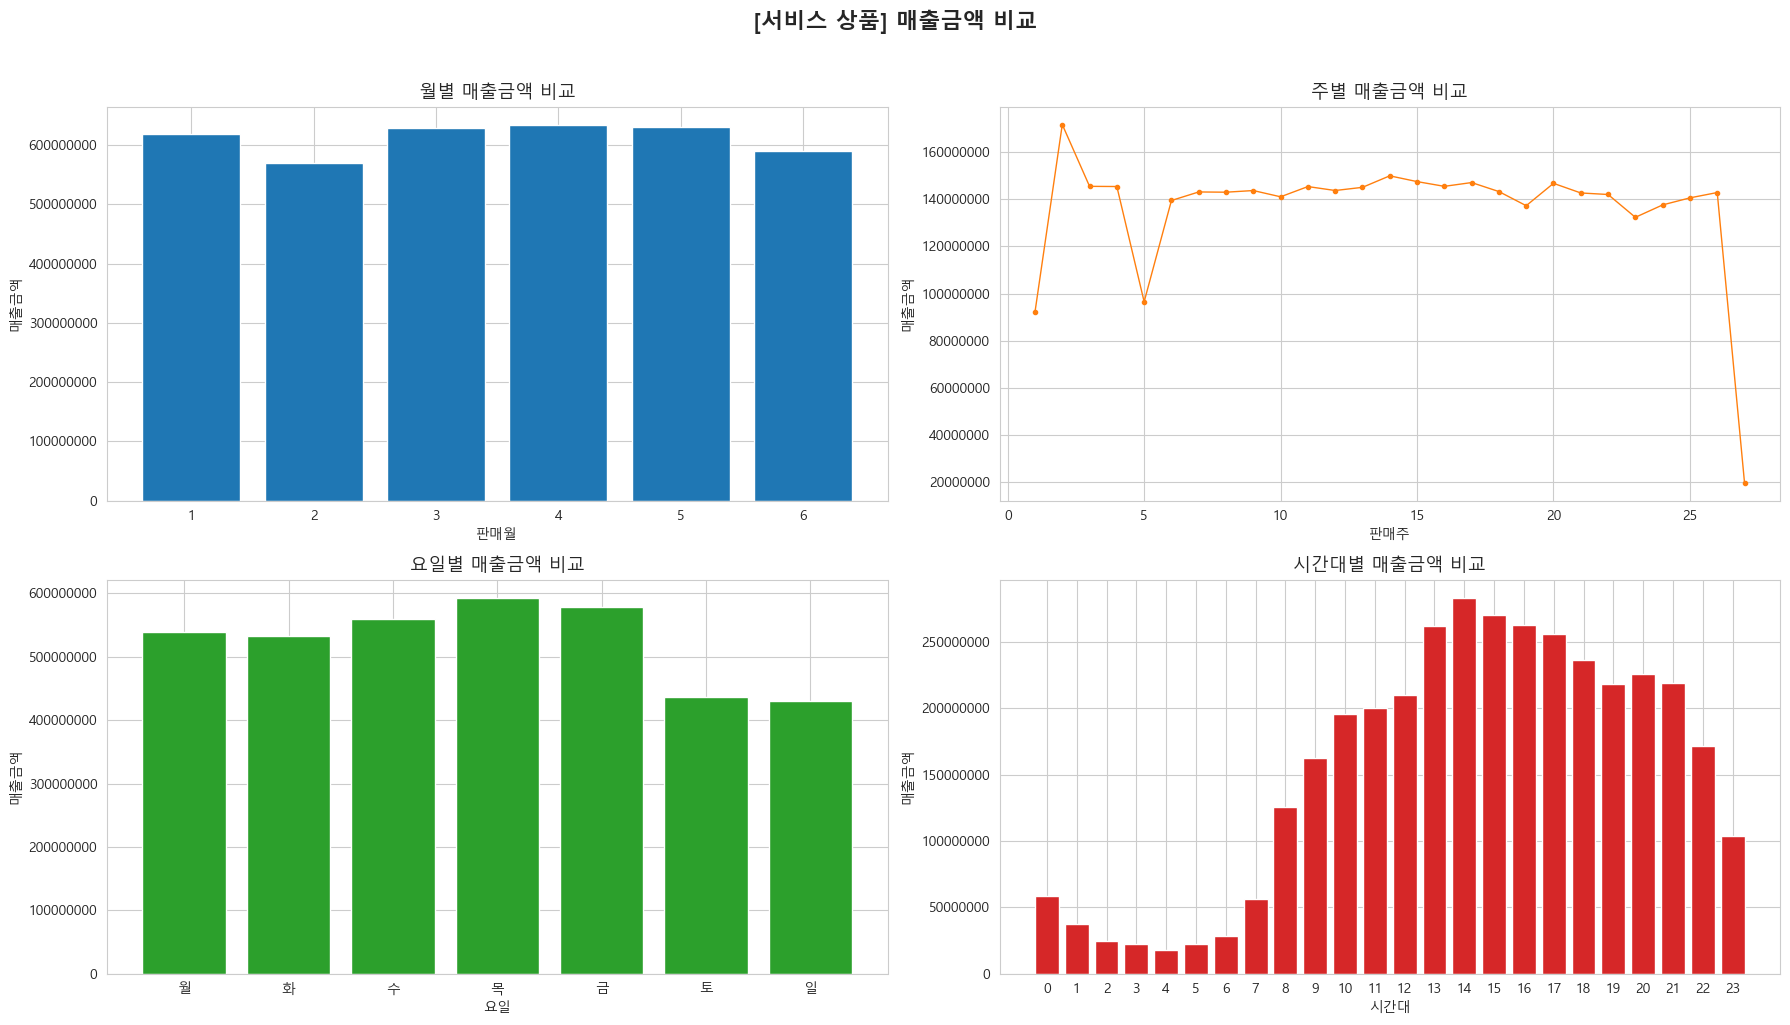

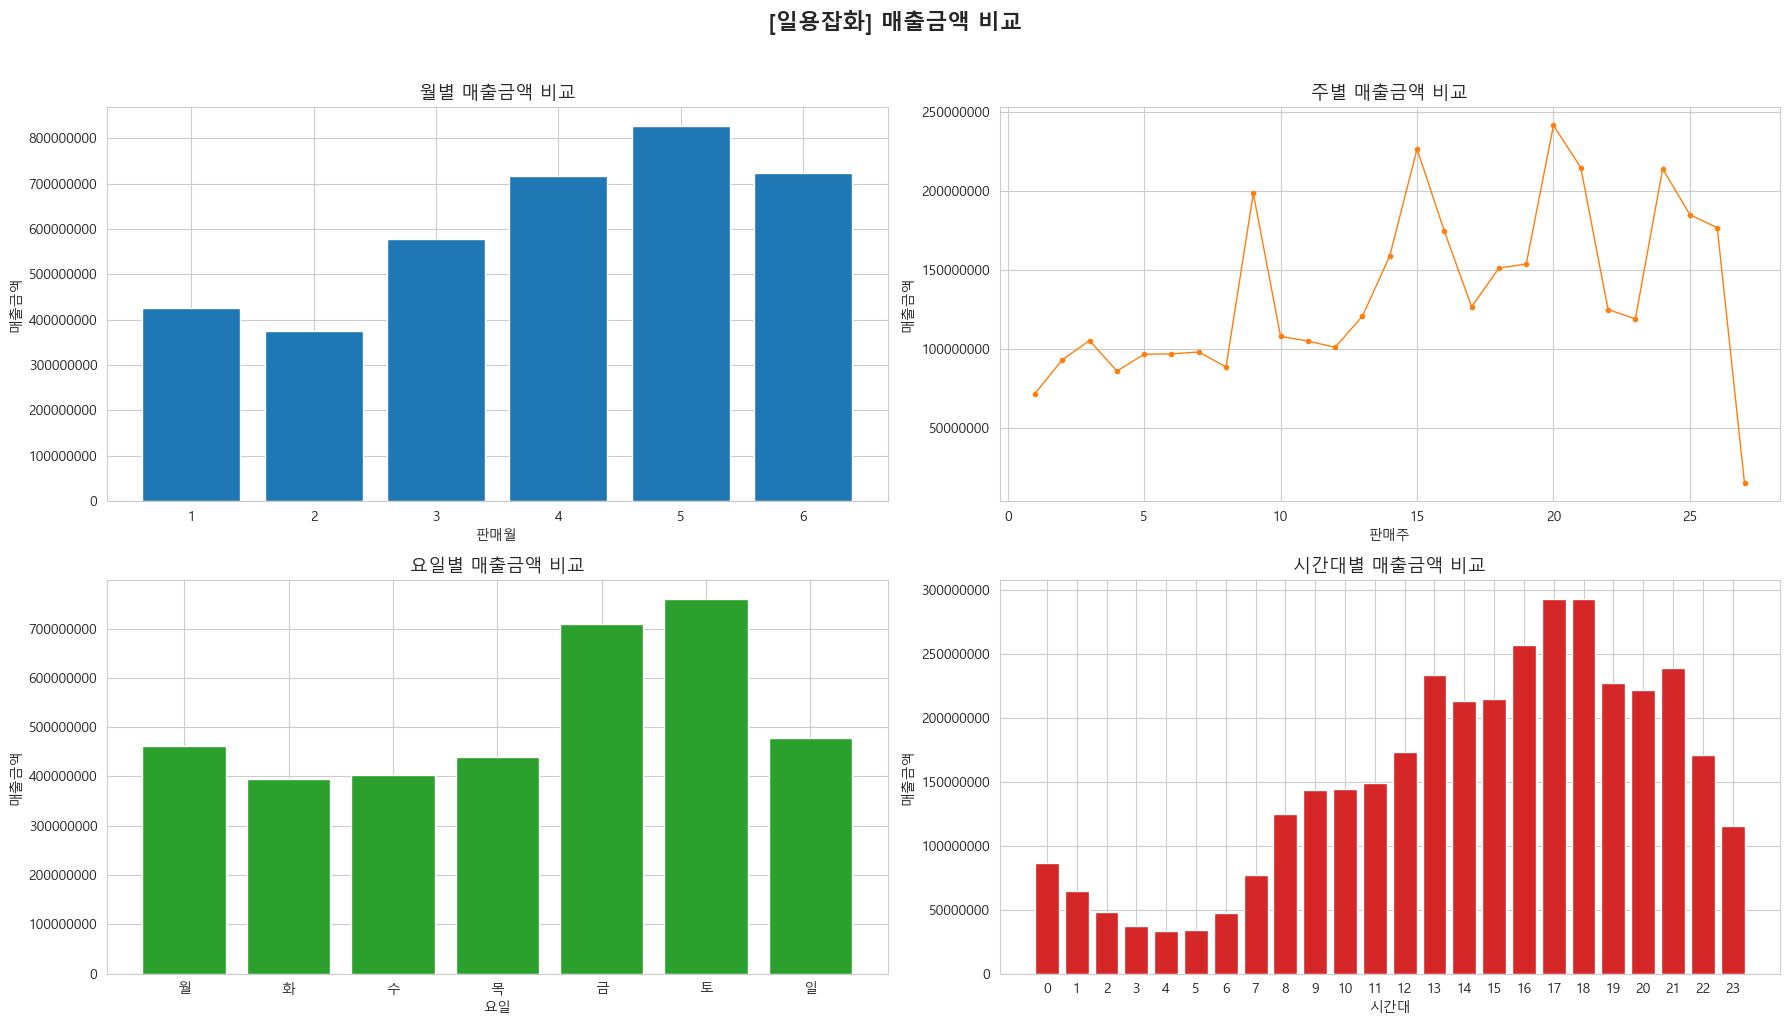

In [44]:
# 13-1. 상위 12개 대분류별 매출금액 비교 (월/주/요일/시간대)

요일이름 = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

# 상위 12개 대분류 선정
top_cats = df.groupby('상품대분류명')['매출금액'].sum().sort_values(ascending=False).head(12).index.tolist()

for cat_name in top_cats:
    cat_df = df[df['상품대분류명'] == cat_name]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'[{cat_name}] 매출금액 비교', fontsize=16, fontweight='bold', y=1.02)
    
    # (1) 판매월별 매출금액
    monthly = cat_df.groupby('판매월')['매출금액'].sum()
    axes[0, 0].bar(monthly.index, monthly.values, color='#1f77b4', edgecolor='white')
    axes[0, 0].set_title('월별 매출금액 비교', fontsize=13)
    axes[0, 0].set_xlabel('판매월')
    axes[0, 0].set_ylabel('매출금액')
    axes[0, 0].set_xticks(monthly.index)
    axes[0, 0].ticklabel_format(style='plain', axis='y')
    
    # (2) 판매주별 매출금액
    weekly = cat_df.groupby('판매주')['매출금액'].sum().sort_index()
    axes[0, 1].plot(weekly.index, weekly.values, marker='o', markersize=3, color='#ff7f0e', linewidth=1)
    axes[0, 1].set_title('주별 매출금액 비교', fontsize=13)
    axes[0, 1].set_xlabel('판매주')
    axes[0, 1].set_ylabel('매출금액')
    axes[0, 1].ticklabel_format(style='plain', axis='y')
    
    # (3) 판매요일별 매출금액
    dow = cat_df.groupby('판매요일')['매출금액'].sum()
    dow.index = dow.index.map(요일이름)
    axes[1, 0].bar(dow.index, dow.values, color='#2ca02c', edgecolor='white')
    axes[1, 0].set_title('요일별 매출금액 비교', fontsize=13)
    axes[1, 0].set_xlabel('요일')
    axes[1, 0].set_ylabel('매출금액')
    axes[1, 0].ticklabel_format(style='plain', axis='y')
    
    # (4) 판매시간대별 매출금액
    hourly = cat_df.groupby('판매시간대')['매출금액'].sum()
    axes[1, 1].bar(hourly.index, hourly.values, color='#d62728', edgecolor='white')
    axes[1, 1].set_title('시간대별 매출금액 비교', fontsize=13)
    axes[1, 1].set_xlabel('시간대')
    axes[1, 1].set_ylabel('매출금액')
    axes[1, 1].set_xticks(hourly.index)
    axes[1, 1].ticklabel_format(style='plain', axis='y')
    
    plt.tight_layout()
    plt.show()

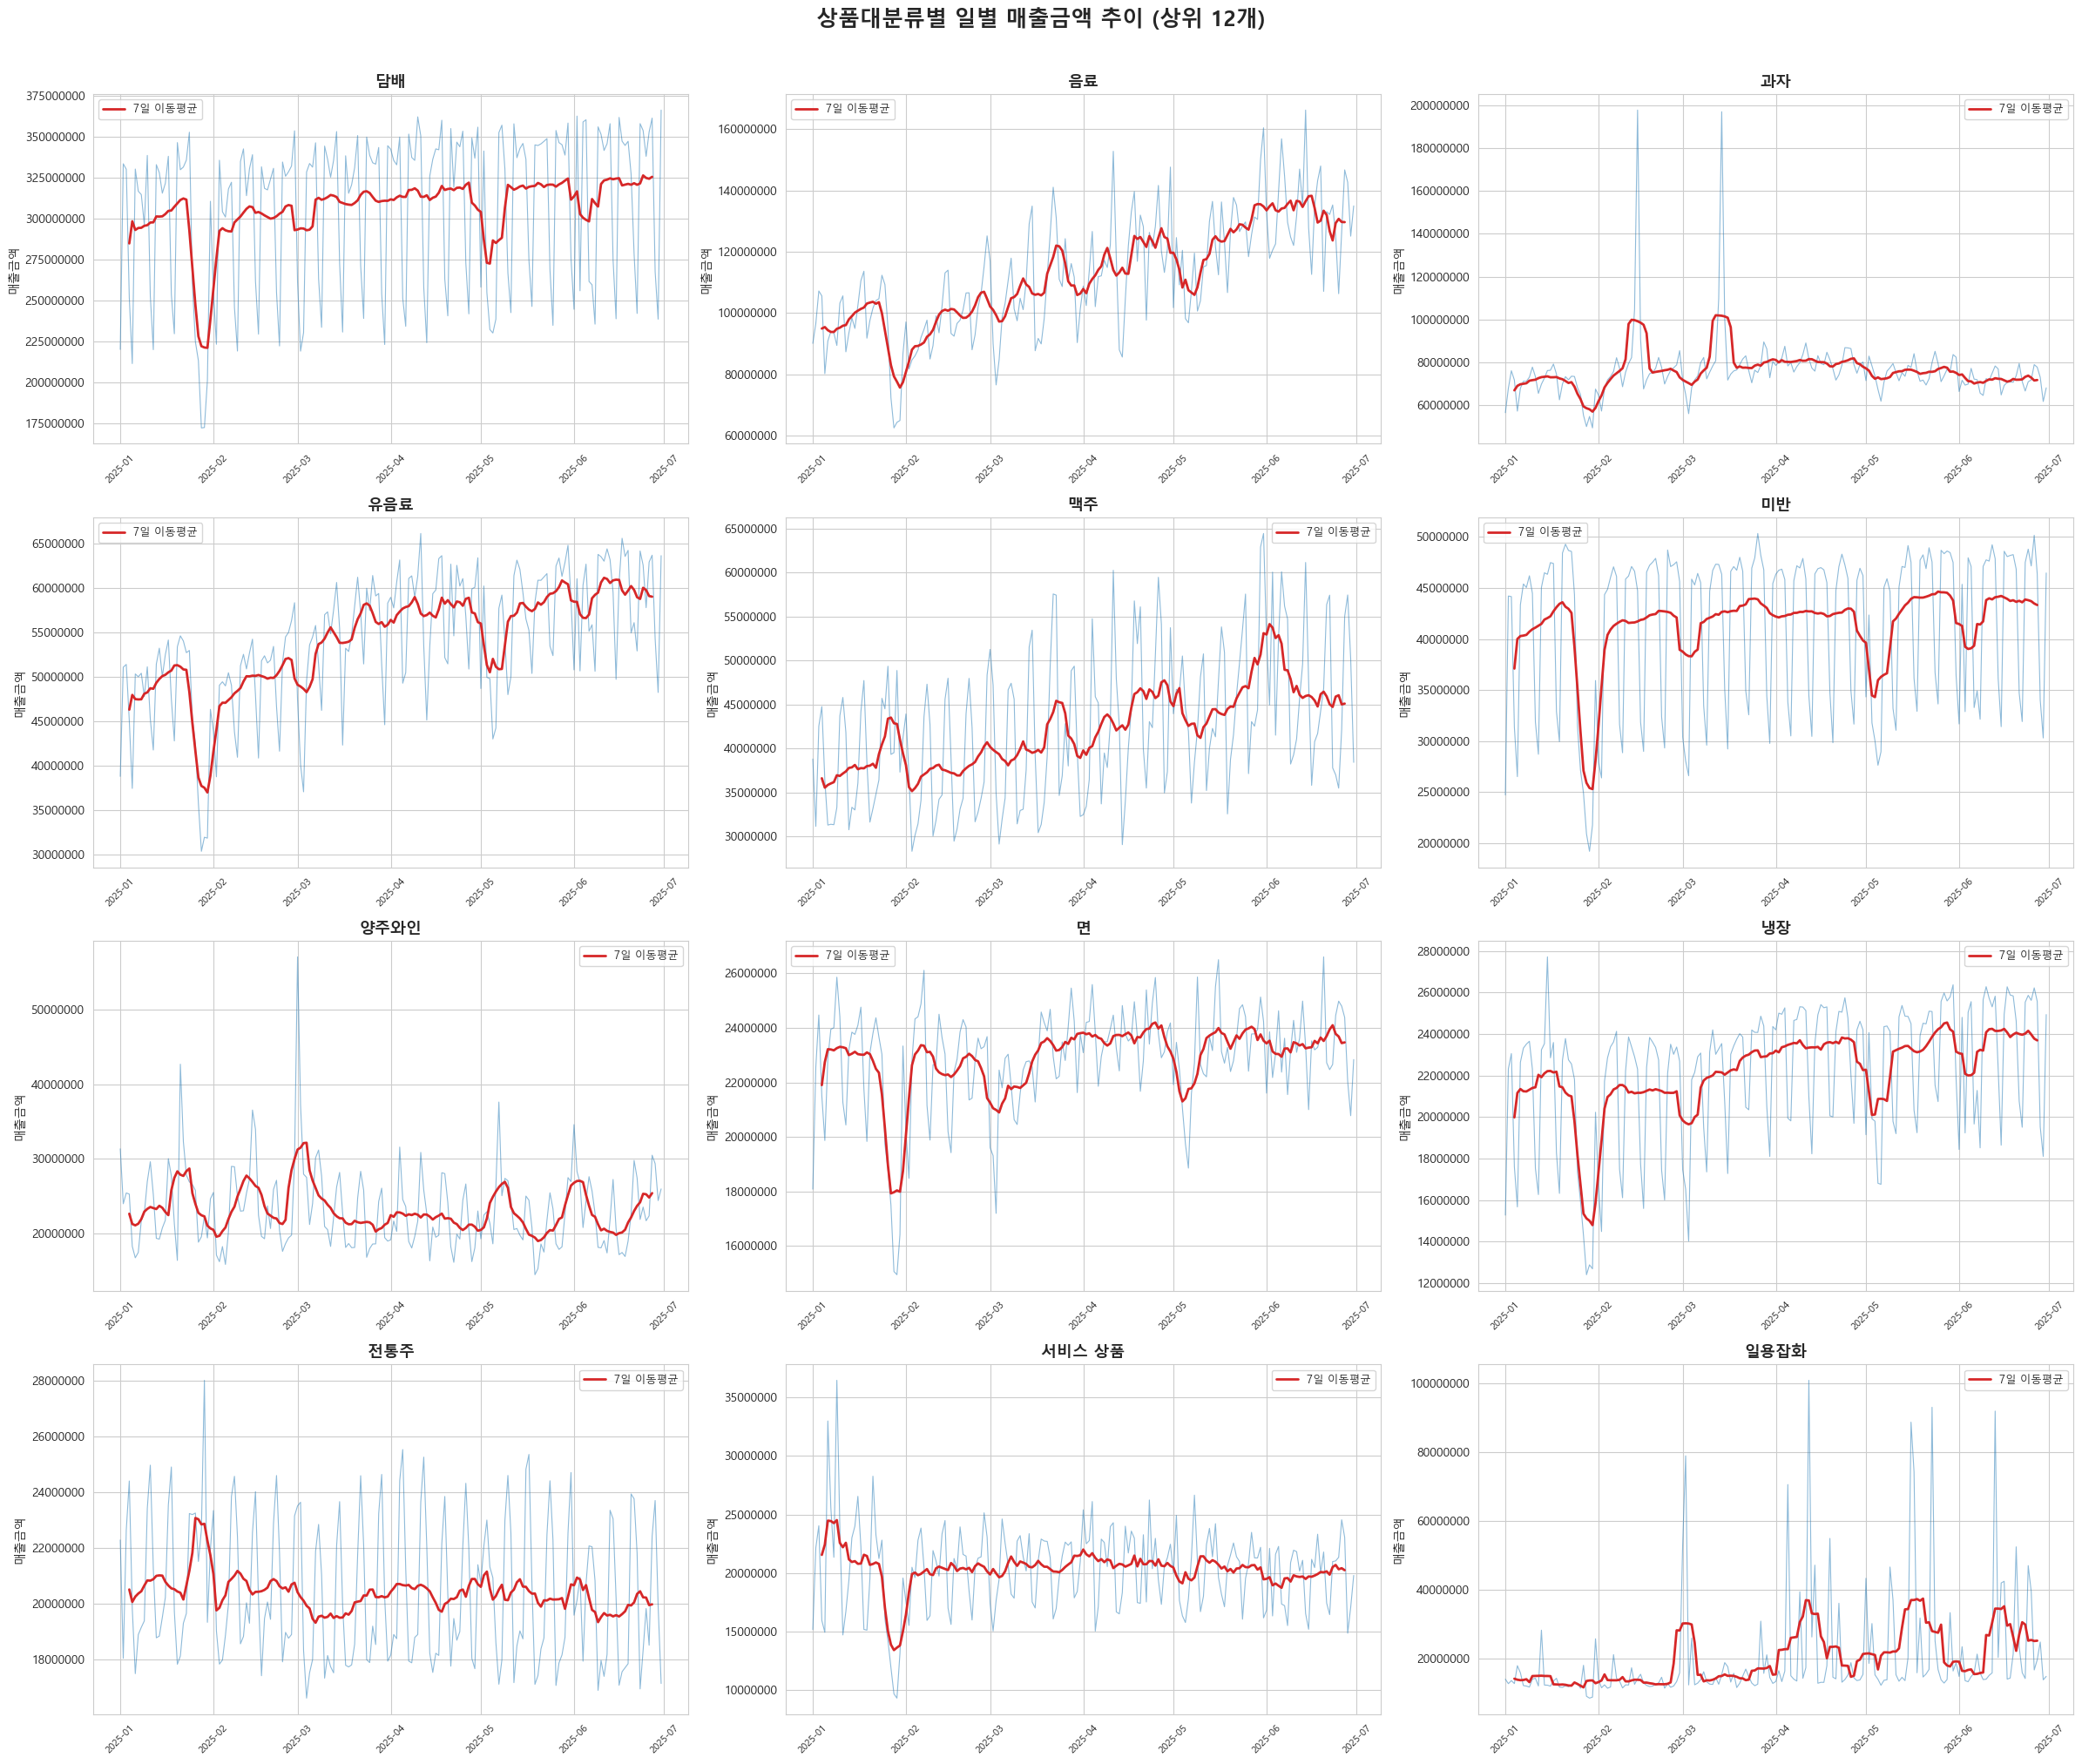

In [43]:
# 13-3. 판매시간_dt 기준 상품대분류별 일별 매출금액 추이

# 일자 추출
df['판매일자'] = df['판매시간_dt'].dt.date

# 상위 12개 대분류
top_cats = df.groupby('상품대분류명')['매출금액'].sum().sort_values(ascending=False).head(12).index.tolist()

# 일별 매출 집계
daily_cat = df[df['상품대분류명'].isin(top_cats)].groupby(['판매일자', '상품대분류명'])['매출금액'].sum().reset_index()

# 4행 3열 subplot
fig, axes = plt.subplots(4, 3, figsize=(24, 20))
fig.suptitle('상품대분류별 일별 매출금액 추이 (상위 12개)', fontsize=18, fontweight='bold', y=1.01)

for idx, cat in enumerate(top_cats):
    ax = axes[idx // 3, idx % 3]
    cat_data = daily_cat[daily_cat['상품대분류명'] == cat].sort_values('판매일자')
    
    ax.plot(cat_data['판매일자'], cat_data['매출금액'], linewidth=0.8, color='#1f77b4', alpha=0.5)
    
    # 7일 이동평균 추가
    if len(cat_data) >= 7:
        cat_data = cat_data.copy()
        cat_data['MA7'] = cat_data['매출금액'].rolling(window=7, center=True).mean()
        ax.plot(cat_data['판매일자'], cat_data['MA7'], linewidth=2, color='#d62728', label='7일 이동평균')
        ax.legend(fontsize=9)
    
    ax.set_title(f'{cat}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('매출금액', fontsize=10)
    ax.ticklabel_format(style='plain', axis='y')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()
